# eGFR Data Explorer

This notebook allows you to explore data for a specific case number from the DuckDB database.

## Available Tables (Bronze Schema):

### 31-08-2025 Data:
- `bronze.egfr_data` - eGFR measurements and patient information
- `bronze.arterial_segmentation` - Arterial phase segmentation data
- `bronze.late_segmentation` - Late phase segmentation data
- `bronze.venous_segmentation` - Venous phase segmentation data

### 25-11-2025 Data:
- `bronze.anon_egfr` - Anonymized eGFR data
- `bronze.anon_segmentations` - Anonymized segmentation data

In [1]:
import duckdb
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

## Load All Data from Database

Load all tables from the bronze schema into pandas DataFrames.

In [2]:
# Connect to the database
db_path = Path('../database/egfr_data.duckdb')
conn = duckdb.connect(str(db_path), read_only=True)

print(f"Connected to database: {db_path}")
print(f"Loading all tables from bronze schema...\n")

# Load 31-08-2025 tables from bronze schema
egfr_df = conn.execute('SELECT * FROM bronze.egfr_data').df()
arterial_df = conn.execute('SELECT * FROM bronze.arterial_segmentation').df()
late_df = conn.execute('SELECT * FROM bronze.late_segmentation').df()
venous_df = conn.execute('SELECT * FROM bronze.venous_segmentation').df()

# Load 25-11-2025 tables from bronze schema
anon_egfr_df = conn.execute('SELECT * FROM bronze.anon_egfr').df()
anon_seg_df = conn.execute('SELECT * FROM bronze.anon_segmentations').df()

# Load gold tables
seg_df = conn.execute('Select * FROM gold.segmentations').df()


# Load the gold table
anon_seg_egfr_df = conn.execute('SELECT * FROM gold.anon_segmentations_with_egfr').df()


# Close connection - we don't need it anymore
conn.close()

print(f"Loaded tables:")
print(f"\n31-08-2025 Data:")
print(f"  - bronze.egfr_data: {len(egfr_df)} rows")
print(f"  - bronze.arterial_segmentation: {len(arterial_df)} rows")
print(f"  - bronze.late_segmentation: {len(late_df)} rows")
print(f"  - bronze.venous_segmentation: {len(venous_df)} rows")
print(f"\n25-11-2025 Data:")
print(f"  - bronze.anon_egfr: {len(anon_egfr_df)} rows")
print(f"  - bronze.anon_segmentations: {len(anon_seg_df)} rows")
print(f"\nAvailable cases (31-08-2025): {sorted(egfr_df['case_number'].unique(), key=int)}")
print(f"\nSegmentations: {sorted(seg_df['case_number'].unique(), key=int)}")



Connected to database: ..\database\egfr_data.duckdb
Loading all tables from bronze schema...

Loaded tables:

31-08-2025 Data:
  - bronze.egfr_data: 1066 rows
  - bronze.arterial_segmentation: 105 rows
  - bronze.late_segmentation: 115 rows
  - bronze.venous_segmentation: 110 rows

25-11-2025 Data:
  - bronze.anon_egfr: 1064 rows
  - bronze.anon_segmentations: 25 rows

Available cases (31-08-2025): ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25']

Segmentations: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25']


## Set Case Number

Change the case number below to explore different cases.

In [3]:
# Set the case number you want to explore
case_test = '3'  # Change this to explore different cases

## eGFR Data (31-08-2025)

Patient information and eGFR measurements for the selected case.

In [4]:
# Filter eGFR data for the case
case_egfr = egfr_df[egfr_df['case_number'] == case_test]

case_egfr = case_egfr.dropna(axis=1, how='all')


print(f"eGFR Data for Case {case_test}")
print(f"Number of records: {len(case_egfr)}")
print("\n" + "="*80)

# Display the data
case_egfr

eGFR Data for Case 3
Number of records: 12



,record_id,redcap_repeat_instrument,redcap_repeat_instance,gfr_date,gfr_type,gfr_value,serum_creatinine,gfr_complete,filename,case_number
891,3,gfr,1,03-01-2017,1,>90,57.0,2,eGFR_3.csv,3
892,3,gfr,2,08-05-2017,1,>90,74.0,2,eGFR_3.csv,3
893,3,gfr,3,27-06-2017,1,>90,74.0,2,eGFR_3.csv,3
894,3,gfr,4,08-03-2018,1,>90,83.0,2,eGFR_3.csv,3
895,3,gfr,5,06-01-2019,1,>90,83.0,2,eGFR_3.csv,3
896,3,gfr,6,08-09-2020,1,>90,77.0,2,eGFR_3.csv,3
897,3,gfr,7,19-11-2020,1,>90,66.0,2,eGFR_3.csv,3
898,3,gfr,8,28-06-2022,1,84,88.0,2,eGFR_3.csv,3
899,3,gfr,9,25-09-2024,1,>90,67.0,2,eGFR_3.csv,3
900,3,gfr,10,31-10-2024,1,>90,65.0,2,eGFR_3.csv,3


### Key eGFR Measurements

In [5]:
# Display key columns if they exist
key_columns = ['gfr_date', 'gfr_value', 'serum_creatinine', 'case_number', 'filename']
available_key_cols = [col for col in key_columns if col in case_egfr.columns]

if available_key_cols and len(case_egfr) > 0:
    print(f"Key measurements for Case {case_test}:")
    display(case_egfr[available_key_cols])
else:
    print("No data found for this case")

Key measurements for Case 3:


,gfr_date,gfr_value,serum_creatinine,case_number,filename
891,03-01-2017,>90,57.0,3,eGFR_3.csv
892,08-05-2017,>90,74.0,3,eGFR_3.csv
893,27-06-2017,>90,74.0,3,eGFR_3.csv
894,08-03-2018,>90,83.0,3,eGFR_3.csv
895,06-01-2019,>90,83.0,3,eGFR_3.csv
896,08-09-2020,>90,77.0,3,eGFR_3.csv
897,19-11-2020,>90,66.0,3,eGFR_3.csv
898,28-06-2022,84,88.0,3,eGFR_3.csv
899,25-09-2024,>90,67.0,3,eGFR_3.csv
900,31-10-2024,>90,65.0,3,eGFR_3.csv


## Arterial Segmentation Data

Arterial phase segmentation measurements for the selected case.

In [6]:
# Filter arterial segmentation data
case_arterial = arterial_df[arterial_df['case_number'] == case_test]

print(f"Arterial Segmentation Data for Case {case_test}")
print(f"Number of segments: {len(case_arterial)}")
if len(case_arterial) > 0 and 'Segment' in case_arterial.columns:
    print(f"Segments: {list(case_arterial['Segment'])}")
print("\n" + "="*80)

# Display the data
case_arterial

Arterial Segmentation Data for Case 3
Number of segments: 5
Segments: ['arterial_threshold_3', 'arterial_renal_artery_right_3', 'arterial_renal_artery_left_3', 'arterial_renal_vein_right_3', 'arterial_renal_vein_left_3']



,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,filename,case_number,table_type
85,arterial_threshold_3,1544117,1048210.00,1048.21000,1544117,1048210.00,1048.21000,173,981,283.903,101.1590,180,508,256,table_arterial_3.csv,3,arterial
86,arterial_renal_artery_right_3,1715,1164.21,1.16421,1715,1164.21,1.16421,173,335,244.731,38.7353,180,300,247,table_arterial_3.csv,3,arterial
87,arterial_renal_artery_left_3,1597,1084.11,1.08411,1597,1084.11,1.08411,173,355,250.023,39.4441,181,310,255,table_arterial_3.csv,3,arterial
88,arterial_renal_vein_right_3,1640,1113.30,1.11330,1640,1113.30,1.11330,173,295,243.729,23.1916,191,271,248,table_arterial_3.csv,3,arterial
89,arterial_renal_vein_left_3,4770,3238.07,3.23807,4770,3238.07,3.23807,173,308,243.719,23.8056,191,274,248,table_arterial_3.csv,3,arterial


## Late Segmentation Data

Late phase segmentation measurements for the selected case.

In [7]:
# Filter late segmentation data
case_late = late_df[late_df['case_number'] == case_test]

print(f"Late Segmentation Data for Case {case_test}")
print(f"Number of segments: {len(case_late)}")
if len(case_late) > 0 and 'Segment' in case_late.columns:
    print(f"Segments: {list(case_late['Segment'])}")
print("\n" + "="*80)

# Display the data
case_late

Late Segmentation Data for Case 3
Number of segments: 5
Segments: ['late_threshold_3', 'late_renal_artery_right_3', 'late_renal_artery_left_3', 'late_renal_vein_right_3', 'late_renal_vein_left_3']



,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,filename,case_number,table_type
85,late_threshold_3,4818231,3270810.00,3270.81000,4818231,3270810.00,3270.81000,28,981,97.5205,112.0250,28,346,50,table_late_3.csv,3,late
86,late_renal_artery_right_3,1793,1217.16,1.21716,1793,1217.16,1.21716,28,122,52.9955,17.4200,29,85,49,table_late_3.csv,3,late
87,late_renal_artery_left_3,1984,1346.82,1.34682,1984,1346.82,1.34682,28,128,57.4259,17.4288,30,87,55,table_late_3.csv,3,late
88,late_renal_vein_right_3,1665,1130.27,1.13027,1665,1130.27,1.13027,28,97,53.5315,13.5851,31,75,52,table_late_3.csv,3,late
89,late_renal_vein_left_3,5382,3653.52,3.65352,5382,3653.52,3.65352,28,120,62.4026,17.5732,32,90,62,table_late_3.csv,3,late


## Venous Segmentation Data

Venous phase segmentation measurements for the selected case.

In [8]:
# Filter venous segmentation data
case_venous = venous_df[venous_df['case_number'] == case_test]

print(f"Venous Segmentation Data for Case {case_test}")
print(f"Number of segments: {len(case_venous)}")
if len(case_venous) > 0 and 'Segment' in case_venous.columns:
    print(f"Segments: {list(case_venous['Segment'])}")
print("\n" + "="*80)

# Display the data
case_venous

Venous Segmentation Data for Case 3
Number of segments: 5
Segments: ['venous_threshold_3', 'venous_renal_artery_right_3', 'venous_renal_artery_left_3', 'venous_renal_vein_right_3', 'venous_renal_vein_left_3']



,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median,filename,case_number,table_type
75,venous_threshold_3,3282836,2795200.000,2795.200000,3282836,2795200.000,2795.200000,108,981,240.381,136.9520,115,540,187,table_venous_3.csv,3,venous
76,venous_renal_artery_right_3,915,779.086,0.779086,915,779.086,0.779086,108,183,133.383,16.7119,109,161,131,table_venous_3.csv,3,venous
77,venous_renal_artery_left_3,913,777.383,0.777383,913,777.383,0.777383,108,206,136.653,21.0364,109,176,132,table_venous_3.csv,3,venous
78,venous_renal_vein_right_3,1054,897.439,0.897439,1054,897.439,0.897439,108,189,138.340,13.8400,115,160,137,table_venous_3.csv,3,venous
79,venous_renal_vein_left_3,3193,2718.710,2.718710,3193,2718.710,2.718710,108,193,136.091,14.9250,111,161,135,table_venous_3.csv,3,venous


## Anonymized eGFR Data (25-11-2025)

Anonymized eGFR data from the 25-11-2025 dataset.

In [9]:
# Display anonymized eGFR data

anon_egfr_df = anon_egfr_df[anon_egfr_df['record_id'] == int(case_test)]

print(f"Anonymized eGFR Data (25-11-2025)")
print(f"Total records: {len(anon_egfr_df)}")
print(f"Columns: {list(anon_egfr_df.columns)}")
print("\n" + "="*80)

# Display the data
anon_egfr_df

Anonymized eGFR Data (25-11-2025)
Total records: 12
Columns: ['record_id', 'redcap_repeat_instance', 'egfr_date', 'egfr_value', 'serum_creatinine']



,record_id,redcap_repeat_instance,egfr_date,egfr_value,serum_creatinine
1052,3,1,03-01-2017,>90,57.0
1053,3,2,08-05-2017,>90,74.0
1054,3,3,27-06-2017,>90,74.0
1055,3,4,08-03-2018,>90,83.0
1056,3,5,06-01-2019,>90,83.0
1057,3,6,08-09-2020,>90,77.0
1058,3,7,19-11-2020,>90,66.0
1059,3,8,28-06-2022,84,88.0
1060,3,9,25-09-2024,>90,67.0
1061,3,10,31-10-2024,>90,65.0


## Anonymized Segmentation Data (25-11-2025)

Anonymized segmentation data from the 25-11-2025 dataset.

In [10]:
# Display anonymized segmentation data
anon_seg_df = anon_seg_df[anon_seg_df['record_id'] == int(case_test)]


print(f"Anonymized Segmentation Data (25-11-2025)")
print(f"Total records: {len(anon_seg_df)}")
print(f"Columns: {list(anon_seg_df.columns)}")
print("\n" + "="*80)

# Display the data
anon_seg_df

Anonymized Segmentation Data (25-11-2025)
Total records: 1
Columns: ['record_id', 'current_age', 'sex', 'scan_date', 'arterial_left_kidney_artery', 'arterial_left_kidney_vein', 'arterial_right_kidney_artery', 'arterial_right_kidney_vein', 'arterial_aorta', 'arterial_venacava_below_kidney', 'arterial_venecava_between_kidney_hepatic', 'arterial_venecava_above_hepatic', 'arterial_right_hepatic_vein', 'arterial_left_hepatic_vein', 'arterial_portal_vein', 'venous_left_kidney_artery', 'venous_left_kidney_vein', 'venous_right_kidney_artery', 'venous_right_kidney_vein', 'venous_aorta', 'venous_venacava_below_kidney', 'venous_venacava_between_kidney_hepatic', 'venous_venacava_above_hepatic', 'venous_right_hepatic_vein', 'venous_left_hepatic_vein', 'venous_portal_vein', 'late_left_kidney_artery', 'late_left_kidney_vein', 'late_right_kidney_vein', 'late_right_kidney_artery', 'late_aorta', 'late_venacava_below_kidney', 'late_venacava_between_kidney_hepatic', 'late_venacava_above_hepatic', 'late_ri

,record_id,current_age,sex,scan_date,arterial_left_kidney_artery,arterial_left_kidney_vein,arterial_right_kidney_artery,arterial_right_kidney_vein,arterial_aorta,arterial_venacava_below_kidney,arterial_venecava_between_kidney_hepatic,arterial_venecava_above_hepatic,arterial_right_hepatic_vein,arterial_left_hepatic_vein,arterial_portal_vein,venous_left_kidney_artery,venous_left_kidney_vein,venous_right_kidney_artery,venous_right_kidney_vein,venous_aorta,venous_venacava_below_kidney,venous_venacava_between_kidney_hepatic,venous_venacava_above_hepatic,venous_right_hepatic_vein,venous_left_hepatic_vein,venous_portal_vein,late_left_kidney_artery,late_left_kidney_vein,late_right_kidney_vein,late_right_kidney_artery,late_aorta,late_venacava_below_kidney,late_venacava_between_kidney_hepatic,late_venacava_above_hepatic,late_right_hepatic_vein,late_left_hepatic_vein,late_portal_vein
24,3,58,male,06-11-2024,262,251,255,249,302,53,197,92,20.0,NaN,240,134,137,132,138,148,61,95,163,182,151,159,61,61,57,58,74,58,61,67,70,61.0,74


## Full table from individual anonymized segmentations with eGFR

Differs from the above, which has newer data.

In [11]:
# Display segmentation data for the selected case
seg_df = seg_df[seg_df['case_number'] == case_test]

print(f"Segmentation Data for Case {case_test}")
print(f"Total records: {len(seg_df)}")
print(f"Columns: {list(seg_df.columns)}")
print("\n" + "="*80)

# Display the data
seg_df



Segmentation Data for Case 3
Total records: 1
Columns: ['case_number', 'arterial_left_kidney_artery', 'arterial_left_kidney_vein', 'arterial_right_kidney_artery', 'arterial_right_kidney_vein', 'venous_left_kidney_artery', 'venous_left_kidney_vein', 'venous_right_kidney_artery', 'venous_right_kidney_vein', 'late_left_kidney_artery', 'late_left_kidney_vein', 'late_right_kidney_artery', 'late_right_kidney_vein']



,case_number,arterial_left_kidney_artery,arterial_left_kidney_vein,arterial_right_kidney_artery,arterial_right_kidney_vein,venous_left_kidney_artery,venous_left_kidney_vein,venous_right_kidney_artery,venous_right_kidney_vein,late_left_kidney_artery,late_left_kidney_vein,late_right_kidney_artery,late_right_kidney_vein
18,3,250.023,243.719,244.731,243.729,136.653,136.091,133.383,138.34,57.4259,62.4026,52.9955,53.5315


## gold.anon_segmentations_with_egfr

In [12]:
record_data = anon_seg_egfr_df[anon_seg_egfr_df['record_id'] == int(case_test)]

record_data[['record_id', 'current_age', 'scan_date', 'egfr_date', 'egfr_value', 'serum_creatinine', 'egfrc',
             'date_diff_days', 
                   'arterial_left_kidney_artery', 'arterial_right_kidney_artery']].head(3)

,record_id,current_age,scan_date,egfr_date,egfr_value,serum_creatinine,egfrc,date_diff_days,arterial_left_kidney_artery,arterial_right_kidney_artery
2,3,58,06-11-2024,01-11-2024,>90,73.0,97.193088,5,262,255


## Calculated eGFR

Sanity check for eGFR calculation.

COMPARISON: Reported eGFR vs Calculated eGFRc

Full Comparison Table:
--------------------------------------------------------------------------------


,record_id,current_age,serum_creatinine,egfr_value,egfrc,difference
0,1,69,82.0,83,83.725219,0.725219
1,2,57,62.0,>90,104.674006,NaN
2,3,58,73.0,>90,97.193088,NaN
3,4,58,48.0,>90,115.470469,NaN
4,5,63,59.0,>90,102.420559,NaN
5,6,52,69.0,>90,103.752510,NaN
6,7,69,68.0,>90,92.627864,NaN
7,8,45,69.0,>90,108.981773,NaN
8,9,69,77.0,88,88.014682,0.014682
9,10,70,73.0,89,89.335971,0.335971



STATISTICS FOR EXACT eGFR VALUES (n=7)
Mean difference (eGFRc - eGFR): 0.20 mL/min/1.73m²
Median difference: 0.34 mL/min/1.73m²
Std Dev of difference: 0.46 mL/min/1.73m²
Min difference: -0.60 mL/min/1.73m²
Max difference: 0.73 mL/min/1.73m²

Correlation (exact values): 1.000

DISTRIBUTION BY REPORTED eGFR VALUE
egfr_value
47            1
66            1
82            1
83            1
88            2
89            1
>90          17
>90 | >90     1
Name: count, dtype: int64

RECORDS WHERE eGFRc < 90 BUT REPORTED eGFR IS '>90'
No discrepancies found - all '>90' records have eGFRc ≥ 90


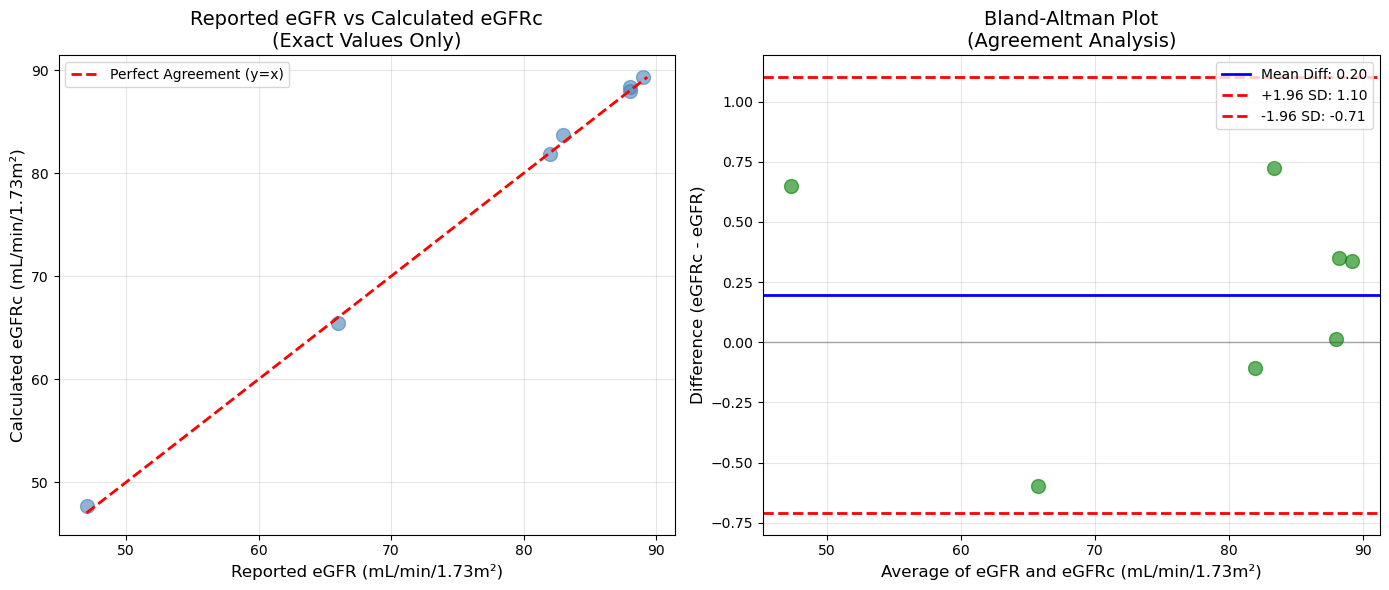


INTERPRETATION NOTES

1. Reported eGFR values with '>' (e.g., '>90') indicate values above that threshold
2. eGFRc is calculated using the CKD-EPI formula with serum creatinine and age
3. Differences may occur due to:
   - Different formulas used (reported vs calculated)
   - Rounding in reported values
   - Additional factors in clinical reporting (e.g., race, which we don't have)
4. The Bland-Altman plot shows agreement between methods
   - Points within ±1.96 SD indicate acceptable agreement



In [13]:
# Create a comparison dataframe
comparison_df = anon_seg_egfr_df[['record_id', 'current_age', 'serum_creatinine', 
                                   'egfr_value', 'egfrc']].copy()

print("="*80)
print("COMPARISON: Reported eGFR vs Calculated eGFRc")
print("="*80)

# Function to convert egfr_value to numeric for comparison
def parse_egfr_value(val):
    """Convert eGFR value to numeric. Returns lower bound for '>90' and '>60' etc."""
    if pd.isna(val):
        return None
    val_str = str(val).strip()
    # Handle compound values like '>90 | >90' - take the first value
    if '|' in val_str:
        val_str = val_str.split('|')[0].strip()
    if val_str.startswith('>'):
        # For '>90', return 90 as the minimum value
        return float(val_str[1:])
    elif val_str.startswith('<'):
        # For '<15', return 15 as the maximum value
        return float(val_str[1:])
    else:
        try:
            return float(val_str)
        except:
            return None

# Parse egfr_value to numeric
comparison_df['egfr_value_numeric'] = comparison_df['egfr_value'].apply(parse_egfr_value)

# Calculate difference (only for exact values, not '>90')
comparison_df['is_exact'] = ~comparison_df['egfr_value'].astype(str).str.contains('>', na=False)
comparison_df['difference'] = comparison_df.apply(
    lambda row: row['egfrc'] - row['egfr_value_numeric'] if row['is_exact'] else None, 
    axis=1
)

# Display the comparison
print("\nFull Comparison Table:")
print("-"*80)
display(comparison_df[['record_id', 'current_age', 'serum_creatinine', 
                       'egfr_value', 'egfrc', 'difference']])

# Statistics for records with exact eGFR values (not '>90')
exact_records = comparison_df[comparison_df['is_exact']].copy()

if len(exact_records) > 0:
    print("\n" + "="*80)
    print(f"STATISTICS FOR EXACT eGFR VALUES (n={len(exact_records)})")
    print("="*80)
    print(f"Mean difference (eGFRc - eGFR): {exact_records['difference'].mean():.2f} mL/min/1.73m²")
    print(f"Median difference: {exact_records['difference'].median():.2f} mL/min/1.73m²")
    print(f"Std Dev of difference: {exact_records['difference'].std():.2f} mL/min/1.73m²")
    print(f"Min difference: {exact_records['difference'].min():.2f} mL/min/1.73m²")
    print(f"Max difference: {exact_records['difference'].max():.2f} mL/min/1.73m²")
    
    # Correlation for exact values
    corr = exact_records[['egfr_value_numeric', 'egfrc']].corr().iloc[0, 1]
    print(f"\nCorrelation (exact values): {corr:.3f}")

# Count by eGFR category
print("\n" + "="*80)
print("DISTRIBUTION BY REPORTED eGFR VALUE")
print("="*80)
print(comparison_df['egfr_value'].value_counts().sort_index())

# Show records where eGFRc suggests different kidney function stage
print("\n" + "="*80)
print("RECORDS WHERE eGFRc < 90 BUT REPORTED eGFR IS '>90'")
print("="*80)
discrepancy = comparison_df[
    (comparison_df['egfr_value'] == '>90') & 
    (comparison_df['egfrc'] < 90)
]
if len(discrepancy) > 0:
    print(f"Found {len(discrepancy)} records:")
    display(discrepancy[['record_id', 'current_age', 'serum_creatinine', 
                         'egfr_value', 'egfrc']])
else:
    print("No discrepancies found - all '>90' records have eGFRc ≥ 90")

# Visualization: Scatter plot for exact values
if len(exact_records) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Scatter plot with identity line
    axes[0].scatter(exact_records['egfr_value_numeric'], exact_records['egfrc'], 
                   s=100, alpha=0.6, color='steelblue')
    
    # Add identity line (y=x)
    min_val = min(exact_records['egfr_value_numeric'].min(), exact_records['egfrc'].min())
    max_val = max(exact_records['egfr_value_numeric'].max(), exact_records['egfrc'].max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
                label='Perfect Agreement (y=x)')
    
    axes[0].set_xlabel('Reported eGFR (mL/min/1.73m²)', fontsize=12)
    axes[0].set_ylabel('Calculated eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[0].set_title('Reported eGFR vs Calculated eGFRc\n(Exact Values Only)', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Bland-Altman plot (difference vs average)
    exact_records['average'] = (exact_records['egfr_value_numeric'] + exact_records['egfrc']) / 2
    mean_diff = exact_records['difference'].mean()
    std_diff = exact_records['difference'].std()
    
    axes[1].scatter(exact_records['average'], exact_records['difference'], 
                   s=100, alpha=0.6, color='green')
    axes[1].axhline(mean_diff, color='blue', linestyle='-', linewidth=2, 
                   label=f'Mean Diff: {mean_diff:.2f}')
    axes[1].axhline(mean_diff + 1.96*std_diff, color='red', linestyle='--', linewidth=2,
                   label=f'+1.96 SD: {mean_diff + 1.96*std_diff:.2f}')
    axes[1].axhline(mean_diff - 1.96*std_diff, color='red', linestyle='--', linewidth=2,
                   label=f'-1.96 SD: {mean_diff - 1.96*std_diff:.2f}')
    axes[1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    
    axes[1].set_xlabel('Average of eGFR and eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[1].set_ylabel('Difference (eGFRc - eGFR)', fontsize=12)
    axes[1].set_title('Bland-Altman Plot\n(Agreement Analysis)', fontsize=14)
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo exact eGFR values available for visualization.")
    print("All records have categorical values like '>90'")

# Summary interpretation
print("\n" + "="*80)
print("INTERPRETATION NOTES")
print("="*80)
print("""
1. Reported eGFR values with '>' (e.g., '>90') indicate values above that threshold
2. eGFRc is calculated using the CKD-EPI formula with serum creatinine and age
3. Differences may occur due to:
   - Different formulas used (reported vs calculated)
   - Rounding in reported values
   - Additional factors in clinical reporting (e.g., race, which we don't have)
4. The Bland-Altman plot shows agreement between methods
   - Points within ±1.96 SD indicate acceptable agreement
""")

## vGFR I

In [14]:
record_data = anon_seg_egfr_df[anon_seg_egfr_df['record_id'] == int(case_test)]

record_data[[
      'record_id', 'current_age', 'scan_date', 'egfr_date',  'date_diff_days', 
       'serum_creatinine', 'egfr_value', 'egfrc',
      'arterial_left_kidney_artery', 'arterial_right_kidney_artery', 'arterial_left_kidney_vein', 'arterial_right_kidney_vein','vgfr_arterial_mean', 
      'venous_left_kidney_artery', 'venous_right_kidney_artery', 'venous_left_kidney_vein', 'venous_right_kidney_vein', 'vgfr_venous_mean', 
      'late_left_kidney_artery', 'late_right_kidney_artery', 'late_left_kidney_vein', 'late_right_kidney_vein', 'vgfr_late_mean'
      ]].head(3)

,record_id,current_age,scan_date,egfr_date,date_diff_days,serum_creatinine,egfr_value,egfrc,arterial_left_kidney_artery,arterial_right_kidney_artery,arterial_left_kidney_vein,arterial_right_kidney_vein,vgfr_arterial_mean,venous_left_kidney_artery,venous_right_kidney_artery,venous_left_kidney_vein,venous_right_kidney_vein,vgfr_venous_mean,late_left_kidney_artery,late_right_kidney_artery,late_left_kidney_vein,late_right_kidney_vein,vgfr_late_mean
2,3,58,06-11-2024,01-11-2024,5,73.0,>90,97.193088,262,255,251,249,19.654243,134,132,137,138,-20.352782,61,58,61,57,5.172414


In [15]:
record_data[[
      'record_id', 'current_age', 'scan_date', 'egfr_date',  'date_diff_days', 
       'serum_creatinine', 'egfr_value', 'egfrc',
      'vgfr_arterial_mean', 
      'vgfr_venous_mean', 
      'vgfr_late_mean'
      ]].head(3)

,record_id,current_age,scan_date,egfr_date,date_diff_days,serum_creatinine,egfr_value,egfrc,vgfr_arterial_mean,vgfr_venous_mean,vgfr_late_mean
2,3,58,06-11-2024,01-11-2024,5,73.0,>90,97.193088,19.654243,-20.352782,5.172414


In [16]:
# Calculate statistics for each phase
print("vGFR STATISTICS BY PHASE")
print("="*80)

phases = ['arterial', 'venous', 'late']

df = anon_seg_egfr_df.copy()

for phase in phases:
    print(f"\n{phase.upper()} PHASE:")
    print("-"*80)
    
    left_col = f'vgfr_{phase}_left'
    right_col = f'vgfr_{phase}_right'
    mean_col = f'vgfr_{phase}_mean'
    
    print(f"Left Kidney:")
    print(f"  Mean: {df[left_col].mean():.2f} mL/min")
    print(f"  Median: {df[left_col].median():.2f} mL/min")
    print(f"  Range: [{df[left_col].min():.2f}, {df[left_col].max():.2f}]")
    
    print(f"\nRight Kidney:")
    print(f"  Mean: {df[right_col].mean():.2f} mL/min")
    print(f"  Median: {df[right_col].median():.2f} mL/min")
    print(f"  Range: [{df[right_col].min():.2f}, {df[right_col].max():.2f}]")
    
    print(f"\nBoth Kidneys (Mean):")
    print(f"  Mean: {df[mean_col].mean():.2f} mL/min")
    print(f"  Median: {df[mean_col].median():.2f} mL/min")
    print(f"  Range: [{df[mean_col].min():.2f}, {df[mean_col].max():.2f}]")

vGFR STATISTICS BY PHASE

ARTERIAL PHASE:
--------------------------------------------------------------------------------
Left Kidney:
  Mean: 200.88 mL/min
  Median: 203.42 mL/min
  Range: [25.19, 373.70]

Right Kidney:
  Mean: 170.25 mL/min
  Median: 173.49 mL/min
  Range: [-39.65, 392.23]

Both Kidneys (Mean):
  Mean: 185.57 mL/min
  Median: 183.31 mL/min
  Range: [-6.07, 382.97]

VENOUS PHASE:
--------------------------------------------------------------------------------
Left Kidney:
  Mean: -14.06 mL/min
  Median: -9.38 mL/min
  Range: [-152.46, 156.10]

Right Kidney:
  Mean: -14.29 mL/min
  Median: 0.00 mL/min
  Range: [-164.06, 94.34]

Both Kidneys (Mean):
  Mean: -14.17 mL/min
  Median: -9.19 mL/min
  Range: [-158.26, 83.76]

LATE PHASE:
--------------------------------------------------------------------------------
Left Kidney:
  Mean: 3.50 mL/min
  Median: 0.00 mL/min
  Range: [-124.14, 101.69]

Right Kidney:
  Mean: 16.62 mL/min
  Median: 10.34 mL/min
  Range: [-79.41, 1

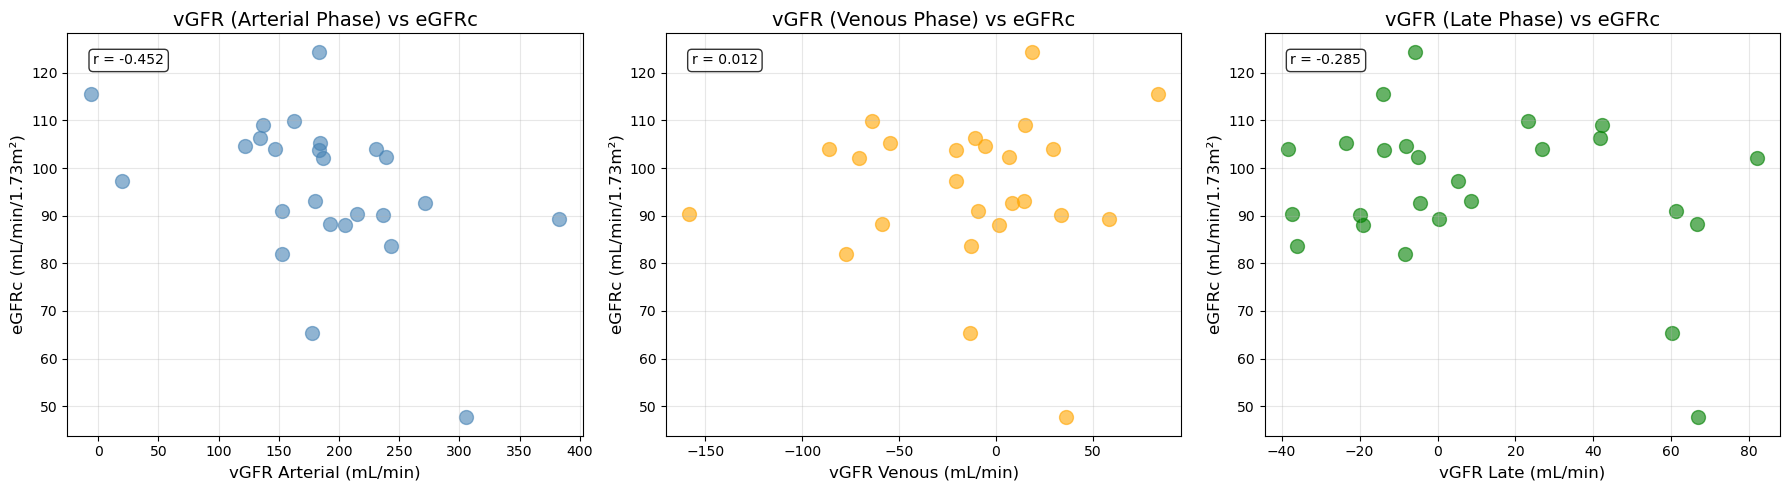

In [17]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    mean_col = f'vgfr_{phase}_mean'
    
    # Swapped: vGFR on x-axis, eGFRc on y-axis
    axes[idx].scatter(df[mean_col], df['egfrc'], alpha=0.6, s=100, color=color)
    axes[idx].set_xlabel(f'vGFR {phase.title()} (mL/min)', fontsize=12)
    axes[idx].set_ylabel('eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[idx].set_title(f'vGFR ({phase.title()} Phase) vs eGFRc', fontsize=14)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    corr = df[['egfrc', mean_col]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [18]:
print("EXTRACTION RATIO ANALYSIS")
print("="*80)

def calc_extraction_ratio(p_ra, p_rv):
    """Calculate extraction ratio E = (P_RA - P_RV) / P_RA"""
    if pd.isna(p_ra) or pd.isna(p_rv) or p_ra == 0:
        return None
    return (p_ra - p_rv) / p_ra

# Calculate extraction ratios
df['E_arterial_left'] = df.apply(lambda row: calc_extraction_ratio(
    row['arterial_left_kidney_artery'], row['arterial_left_kidney_vein']), axis=1)
df['E_arterial_right'] = df.apply(lambda row: calc_extraction_ratio(
    row['arterial_right_kidney_artery'], row['arterial_right_kidney_vein']), axis=1)

df['E_venous_left'] = df.apply(lambda row: calc_extraction_ratio(
    row['venous_left_kidney_artery'], row['venous_left_kidney_vein']), axis=1)
df['E_venous_right'] = df.apply(lambda row: calc_extraction_ratio(
    row['venous_right_kidney_artery'], row['venous_right_kidney_vein']), axis=1)

df['E_late_left'] = df.apply(lambda row: calc_extraction_ratio(
    row['late_left_kidney_artery'], row['late_left_kidney_vein']), axis=1)
df['E_late_right'] = df.apply(lambda row: calc_extraction_ratio(
    row['late_right_kidney_artery'], row['late_right_kidney_vein']), axis=1)

# Display statistics
print("\nExtraction Ratio Statistics:")
print("-"*80)

for phase in ['arterial', 'venous', 'late']:
    left_col = f'E_{phase}_left'
    right_col = f'E_{phase}_right'
    
    print(f"\n{phase.upper()} Phase:")
    print(f"  Left:  Mean = {df[left_col].mean():.3f}, Range = [{df[left_col].min():.3f}, {df[left_col].max():.3f}]")
    print(f"  Right: Mean = {df[right_col].mean():.3f}, Range = [{df[right_col].min():.3f}, {df[right_col].max():.3f}]")

# Note about negative values
print("\n" + "="*80)
print("NOTE: Negative extraction ratios occur when P_RV > P_RA")
print("This may indicate:")
print("  - Measurement artifacts")
print("  - Recirculation effects")
print("  - Phase-specific physiology")
print("  - Need for quality control filtering")

EXTRACTION RATIO ANALYSIS

Extraction Ratio Statistics:
--------------------------------------------------------------------------------

ARTERIAL Phase:
  Left:  Mean = 0.335, Range = [0.042, 0.623]
  Right: Mean = 0.284, Range = [-0.066, 0.654]

VENOUS Phase:
  Left:  Mean = -0.023, Range = [-0.254, 0.260]
  Right: Mean = -0.024, Range = [-0.273, 0.157]

LATE Phase:
  Left:  Mean = 0.006, Range = [-0.207, 0.169]
  Right: Mean = 0.028, Range = [-0.132, 0.237]

NOTE: Negative extraction ratios occur when P_RV > P_RA
This may indicate:
  - Measurement artifacts
  - Recirculation effects
  - Phase-specific physiology
  - Need for quality control filtering


C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_42176\1673226290.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vgfr_data_melted, x='Phase', y='vGFR', palette='Set2')


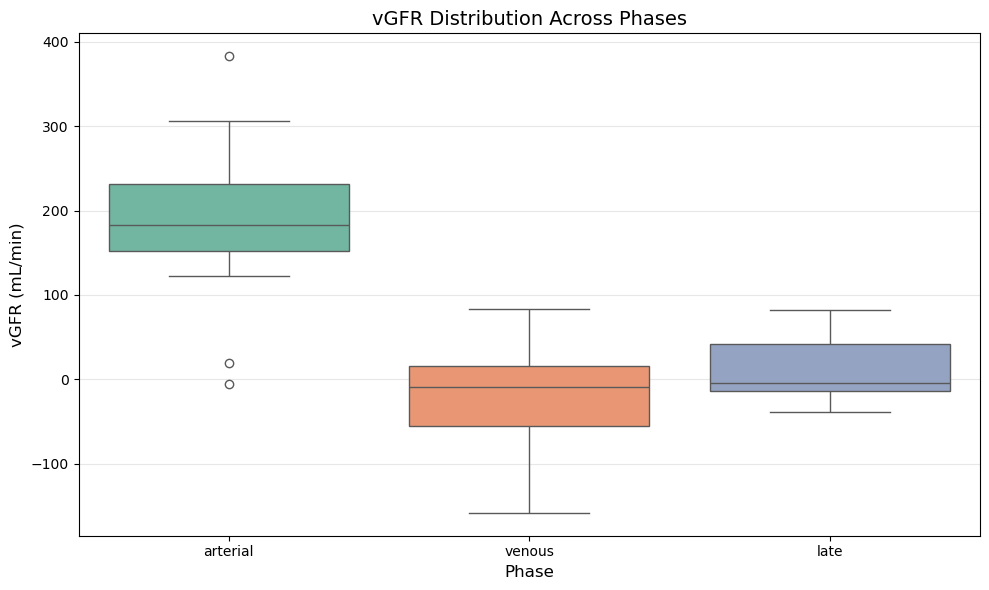


Phase Comparison:
          count        mean        std         min         25%         50%  \
Phase                                                                        
arterial   25.0  185.566730  79.193003   -6.073789  152.564489  183.308010   
late       25.0   10.060805  36.171818  -38.333333  -13.993453   -4.615385   
venous     25.0  -14.172261  52.079941 -158.260758  -54.802260   -9.191108   

                 75%         max  
Phase                             
arterial  230.900134  382.967716  
late       41.666667   81.881940  
venous     15.267968   83.763066  


In [19]:
# Compare vGFR across phases
import seaborn as sns

# Prepare data for visualization
vgfr_data = df[['record_id', 'vgfr_arterial_mean', 'vgfr_venous_mean', 'vgfr_late_mean']].copy()
vgfr_data_melted = vgfr_data.melt(id_vars='record_id', 
                                   var_name='Phase', 
                                   value_name='vGFR')
vgfr_data_melted['Phase'] = vgfr_data_melted['Phase'].str.replace('vgfr_', '').str.replace('_mean', '')

# Create box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=vgfr_data_melted, x='Phase', y='vGFR', palette='Set2')
plt.xlabel('Phase', fontsize=12)
plt.ylabel('vGFR (mL/min)', fontsize=12)
plt.title('vGFR Distribution Across Phases', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Statistical comparison
print("\nPhase Comparison:")
print("="*80)
print(vgfr_data_melted.groupby('Phase')['vGFR'].describe())

---

# HU-to-Concentration Conversion Methods

This section explores the two methods for converting Hounsfield Units (HU) to iodine concentration:

## Method 1: Literature-Based Baseline (HU = 45)
- Formula: `Concentration = (HU - 45) / 25`
- Uses standard baseline for blood vessels
- **Recommended for most analyses**

## Method 2: Late Phase Pseudo-Baseline
- Formula: `Concentration = (HU_phase - HU_late) / 25`
- Patient-specific baseline
- Accounts for individual tissue density

In [20]:
# Display concentration columns for a specific record
record_id_to_explore = 22  # Change this to explore different records

# Filter data
record_data = anon_seg_egfr_df[anon_seg_egfr_df['record_id'] == record_id_to_explore]

if len(record_data) > 0:
    print(f"Concentration Data for Record ID {record_id_to_explore}")
    print("=" * 80)
    
    # Arterial phase concentrations
    print("\nArterial Phase - Left Kidney:")
    print(f"  Raw HU (artery): {record_data['arterial_left_kidney_artery'].values[0]}")
    print(f"  Raw HU (vein):   {record_data['arterial_left_kidney_vein'].values[0]}")
    print(f"  Conc (Lit baseline) artery: {record_data['conc_lit_arterial_left_artery'].values[0]:.2f} mg/mL")
    print(f"  Conc (Lit baseline) vein:   {record_data['conc_lit_arterial_left_vein'].values[0]:.2f} mg/mL")
    print(f"  Conc (Late baseline) artery: {record_data['conc_late_arterial_left_artery'].values[0]:.2f} mg/mL")
    print(f"  Conc (Late baseline) vein:   {record_data['conc_late_arterial_left_vein'].values[0]:.2f} mg/mL")
    
    # Display full concentration table
    conc_cols = ['record_id',
                 'conc_lit_arterial_left_artery', 'conc_lit_arterial_left_vein',
                 'conc_late_arterial_left_artery', 'conc_late_arterial_left_vein']
    
    print("\n" + "=" * 80)
    print("Full Concentration Table:")
    print("=" * 80)
    display(record_data[conc_cols].T)
else:
    print(f"No data found for record_id {record_id_to_explore}")

Concentration Data for Record ID 22

Arterial Phase - Left Kidney:
  Raw HU (artery): 249
  Raw HU (vein):   169
  Conc (Lit baseline) artery: 8.16 mg/mL
  Conc (Lit baseline) vein:   4.96 mg/mL
  Conc (Late baseline) artery: 7.04 mg/mL
  Conc (Late baseline) vein:   4.16 mg/mL

Full Concentration Table:


,21
record_id,22.00
conc_lit_arterial_left_artery,8.16
conc_lit_arterial_left_vein,4.96
conc_late_arterial_left_artery,7.04
conc_late_arterial_left_vein,4.16


## vGFR Comparison Across Methods

Compare vGFR calculated using three different approaches:
1. **Raw HU** - Direct calculation from HU values
2. **Literature Baseline** - Using HU = 45 baseline
3. **Late Phase Baseline** - Using patient-specific late phase as baseline

In [21]:
# Compare vGFR methods
vgfr_comparison = anon_seg_egfr_df[[
    'record_id',
    'vgfr_arterial_mean',      # Raw HU
    'vgfr_lit_arterial_mean',  # Literature baseline
    'vgfr_late_arterial_mean', # Late phase baseline
    'vgfr_venous_mean',
    'vgfr_lit_venous_mean',
    'vgfr_late_venous_mean'
]].copy()

vgfr_comparison.columns = [
    'Record ID',
    'Arterial (HU)', 'Arterial (Lit)', 'Arterial (Late)',
    'Venous (HU)', 'Venous (Lit)', 'Venous (Late)'
]

print("vGFR Comparison Across Methods (mL/min)")
print("=" * 80)
display(vgfr_comparison.head(10))

# Statistics
print("\nStatistics:")
print("=" * 80)
display(vgfr_comparison.describe())

vGFR Comparison Across Methods (mL/min)


,Record ID,Arterial (HU),Arterial (Lit),Arterial (Late),Venous (HU),Venous (Lit),Venous (Late)
0,1,243.144929,303.010541,293.782895,-12.658802,-69.104952,2.553191
1,2,122.388337,148.408561,158.988764,-5.330634,-8.876812,-6.320755
2,3,19.654243,23.778802,24.032124,-20.352782,-30.802015,-40.707146
3,4,-6.073789,-7.802198,-3.971631,83.763066,133.076923,157.795046
4,5,239.079513,274.933055,302.847594,6.683007,10.036630,17.302053
5,6,183.308010,219.699037,246.493014,-20.646104,-36.967546,-32.432432
6,7,271.591044,310.838509,333.249763,8.449411,12.367021,19.523471
7,8,136.573496,161.485194,163.205742,15.267968,20.468960,-2.714932
8,9,205.059551,241.893227,274.640959,1.881843,2.553693,13.992095
9,10,382.967716,450.856930,520.011148,58.708273,82.005690,114.092664



Statistics:


,Record ID,Arterial (HU),Arterial (Lit),Arterial (Late),Venous (HU),Venous (Lit),Venous (Late)
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,13.000000,185.566730,219.106457,233.818911,-14.172261,-27.931623,-56.359877
std,7.359801,79.193003,92.023511,103.421442,52.079941,83.450512,131.864171
min,1.000000,-6.073789,-7.802198,-3.971631,-158.260758,-247.285245,-415.000000
25%,7.000000,152.564489,178.917250,191.719414,-54.802260,-87.569762,-93.973635
50%,13.000000,183.308010,215.113533,227.719298,-9.191108,-16.949649,-6.320755
75%,19.000000,230.900134,269.099757,293.782895,15.267968,22.461538,17.302053
max,25.000000,382.967716,450.856930,520.011148,83.763066,133.076923,157.795046


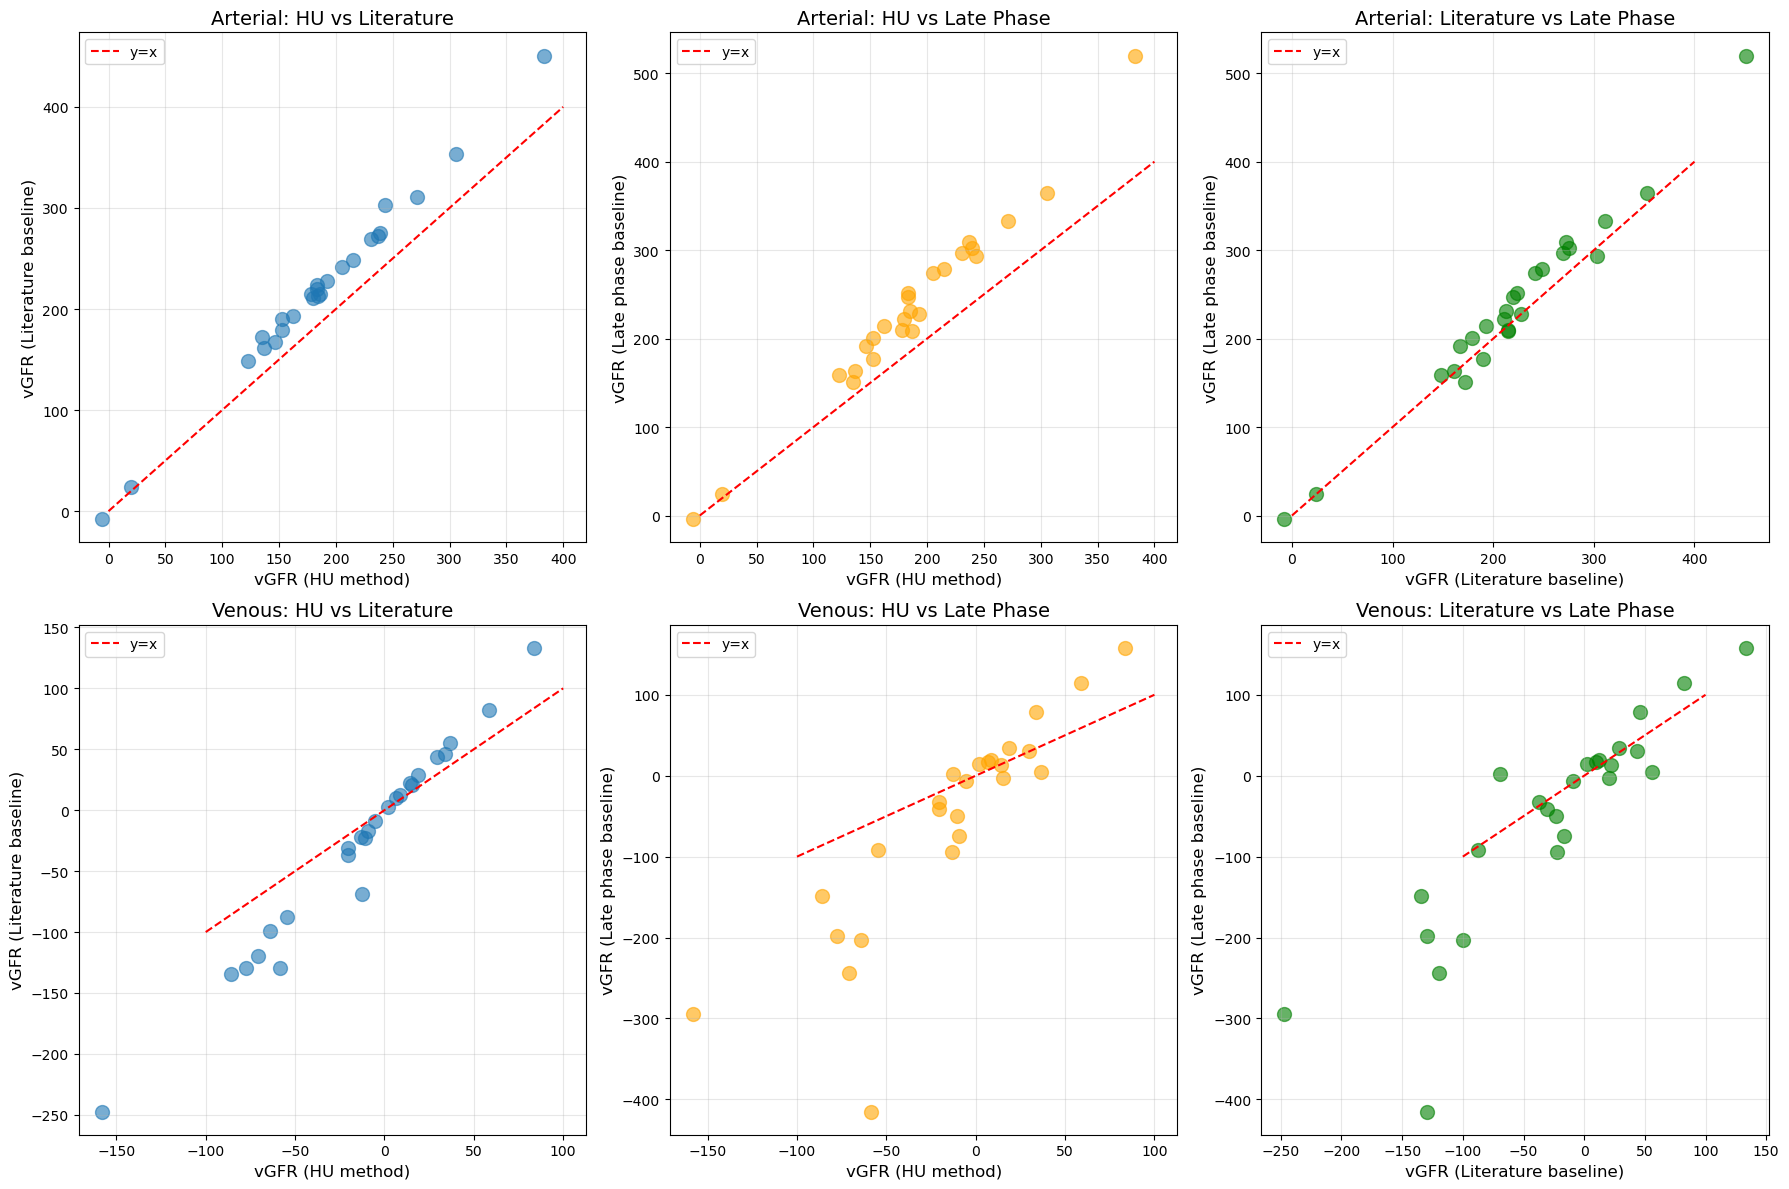


Correlations between methods:

ARTERIAL Phase:
  HU vs Literature:  0.998
  HU vs Late Phase:  0.990
  Lit vs Late Phase: 0.987

VENOUS Phase:
  HU vs Literature:  0.990
  HU vs Late Phase:  0.868
  Lit vs Late Phase: 0.888


In [22]:
# Visualize method comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Arterial phase comparisons
axes[0, 0].scatter(anon_seg_egfr_df['vgfr_arterial_mean'], 
                   anon_seg_egfr_df['vgfr_lit_arterial_mean'], alpha=0.6, s=100)
axes[0, 0].plot([0, 400], [0, 400], 'r--', label='y=x')
axes[0, 0].set_xlabel('vGFR (HU method)', fontsize=12)
axes[0, 0].set_ylabel('vGFR (Literature baseline)', fontsize=12)
axes[0, 0].set_title('Arterial: HU vs Literature', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(anon_seg_egfr_df['vgfr_arterial_mean'], 
                   anon_seg_egfr_df['vgfr_late_arterial_mean'], 
                   alpha=0.6, s=100, color='orange')
axes[0, 1].plot([0, 400], [0, 400], 'r--', label='y=x')
axes[0, 1].set_xlabel('vGFR (HU method)', fontsize=12)
axes[0, 1].set_ylabel('vGFR (Late phase baseline)', fontsize=12)
axes[0, 1].set_title('Arterial: HU vs Late Phase', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(anon_seg_egfr_df['vgfr_lit_arterial_mean'], 
                   anon_seg_egfr_df['vgfr_late_arterial_mean'], 
                   alpha=0.6, s=100, color='green')
axes[0, 2].plot([0, 400], [0, 400], 'r--', label='y=x')
axes[0, 2].set_xlabel('vGFR (Literature baseline)', fontsize=12)
axes[0, 2].set_ylabel('vGFR (Late phase baseline)', fontsize=12)
axes[0, 2].set_title('Arterial: Literature vs Late Phase', fontsize=14)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Venous phase comparisons
axes[1, 0].scatter(anon_seg_egfr_df['vgfr_venous_mean'], 
                   anon_seg_egfr_df['vgfr_lit_venous_mean'], alpha=0.6, s=100)
axes[1, 0].plot([-100, 100], [-100, 100], 'r--', label='y=x')
axes[1, 0].set_xlabel('vGFR (HU method)', fontsize=12)
axes[1, 0].set_ylabel('vGFR (Literature baseline)', fontsize=12)
axes[1, 0].set_title('Venous: HU vs Literature', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(anon_seg_egfr_df['vgfr_venous_mean'], 
                   anon_seg_egfr_df['vgfr_late_venous_mean'], 
                   alpha=0.6, s=100, color='orange')
axes[1, 1].plot([-100, 100], [-100, 100], 'r--', label='y=x')
axes[1, 1].set_xlabel('vGFR (HU method)', fontsize=12)
axes[1, 1].set_ylabel('vGFR (Late phase baseline)', fontsize=12)
axes[1, 1].set_title('Venous: HU vs Late Phase', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(anon_seg_egfr_df['vgfr_lit_venous_mean'], 
                   anon_seg_egfr_df['vgfr_late_venous_mean'], 
                   alpha=0.6, s=100, color='green')
axes[1, 2].plot([-100, 100], [-100, 100], 'r--', label='y=x')
axes[1, 2].set_xlabel('vGFR (Literature baseline)', fontsize=12)
axes[1, 2].set_ylabel('vGFR (Late phase baseline)', fontsize=12)
axes[1, 2].set_title('Venous: Literature vs Late Phase', fontsize=14)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlations
print("\nCorrelations between methods:")
print("=" * 80)
for phase in ['arterial', 'venous']:
    hu_col = f'vgfr_{phase}_mean'
    lit_col = f'vgfr_lit_{phase}_mean'
    late_col = f'vgfr_late_{phase}_mean'
    
    print(f"\n{phase.upper()} Phase:")
    print(f"  HU vs Literature:  {anon_seg_egfr_df[[hu_col, lit_col]].corr().iloc[0,1]:.3f}")
    print(f"  HU vs Late Phase:  {anon_seg_egfr_df[[hu_col, late_col]].corr().iloc[0,1]:.3f}")
    print(f"  Lit vs Late Phase: {anon_seg_egfr_df[[lit_col, late_col]].corr().iloc[0,1]:.3f}")

## Compare vGFR Methods with eGFRc

Compare all three vGFR methods with the calculated eGFRc to see which correlates best with systemic kidney function.

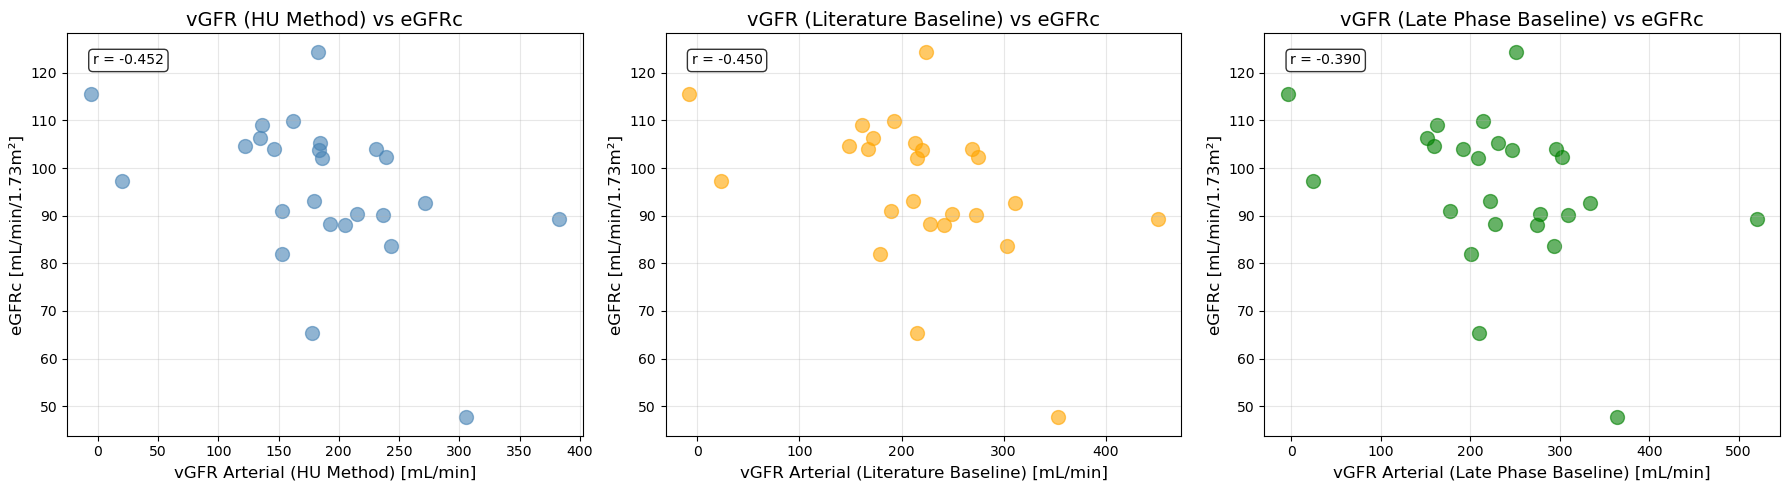


Correlation with eGFRc (Arterial Phase):
HU Method                : r = -0.452
Literature Baseline      : r = -0.450
Late Phase Baseline      : r = -0.390


In [23]:
# Create comparison plots with eGFRc
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ('vgfr_arterial_mean', 'HU Method', 'steelblue'),
    ('vgfr_lit_arterial_mean', 'Literature Baseline', 'orange'),
    ('vgfr_late_arterial_mean', 'Late Phase Baseline', 'green')
]

for idx, (col, name, color) in enumerate(methods):
    # Swapped axes: vGFR on x-axis, eGFRc on y-axis
    axes[idx].scatter(anon_seg_egfr_df[col], anon_seg_egfr_df['egfrc'], 
                     alpha=0.6, s=100, color=color)
    axes[idx].set_xlabel(f'vGFR Arterial ({name}) [mL/min]', fontsize=12)
    axes[idx].set_ylabel('eGFRc [mL/min/1.73m²]', fontsize=12)
    axes[idx].set_title(f'vGFR ({name}) vs eGFRc', fontsize=14)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    corr = anon_seg_egfr_df[['egfrc', col]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print correlation summary
print("\nCorrelation with eGFRc (Arterial Phase):")
print("=" * 80)
for col, name, _ in methods:
    corr = anon_seg_egfr_df[['egfrc', col]].corr().iloc[0, 1]
    print(f"{name:25s}: r = {corr:.3f}")

---

# Wavefront Correction (W_pv)

This section explores the wavefront correction factor that accounts for systemic circulation effects.

## Formula:
```
W_pv = P_portal_vein / P_aorta

vGFR_corrected = RPF × (P_RA - P_RV × W_pv) / P_RA
```

## Purpose:
- Corrects renal vein concentration for systemic recirculation
- Accounts for portal-systemic circulation ratio
- Typically increases vGFR by reducing effective P_RV

In [24]:
# Display wavefront correction factors for a specific record
record_id_wf = 22  # Change this to explore different records

# Filter data
record_wf = anon_seg_egfr_df[anon_seg_egfr_df['record_id'] == record_id_wf]

if len(record_wf) > 0:
    print(f"Wavefront Correction Factors for Record ID {record_id_wf}")
    print("=" * 80)
    
    print("\nW_pv Values by Phase:")
    print(f"  Arterial: {record_wf['w_pv_arterial'].values[0]:.3f}")
    print(f"  Venous:   {record_wf['w_pv_venous'].values[0]:.3f}")
    print(f"  Late:     {record_wf['w_pv_late'].values[0]:.3f}")
    
    print("\nInterpretation:")
    print(f"  Portal vein has ~{record_wf['w_pv_arterial'].values[0]*100:.1f}% of aortic concentration (arterial phase)")
    
    # Display full W_pv table
    w_pv_cols = ['record_id', 'w_pv_arterial', 'w_pv_venous', 'w_pv_late']
    
    print("\n" + "=" * 80)
    print("All W_pv Values:")
    print("=" * 80)
    display(record_wf[w_pv_cols].T)
else:
    print(f"No data found for record_id {record_id_wf}")

Wavefront Correction Factors for Record ID 22

W_pv Values by Phase:
  Arterial: 0.553
  Venous:   0.993
  Late:     0.911

Interpretation:
  Portal vein has ~55.3% of aortic concentration (arterial phase)

All W_pv Values:


,21
record_id,22.000000
w_pv_arterial,0.552529
w_pv_venous,0.993103
w_pv_late,0.911392


W_pv Statistics Across All Records

ARTERIAL Phase:
  Mean:   0.430
  Median: 0.458
  Std:    0.168
  Range:  [0.025, 0.795]

VENOUS Phase:
  Mean:   1.043
  Median: 1.047
  Std:    0.091
  Range:  [0.911, 1.217]

LATE Phase:
  Mean:   0.975
  Median: 0.988
  Std:    0.058
  Range:  [0.776, 1.041]


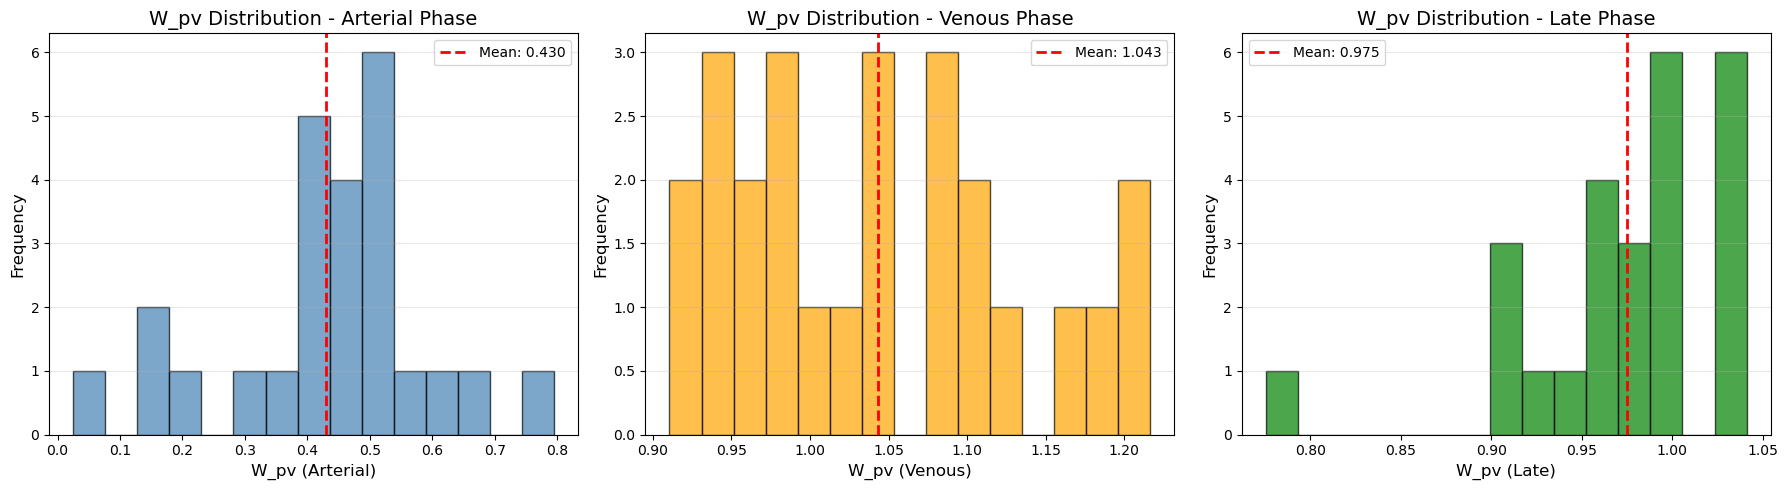

In [25]:
# W_pv statistics across all records
print("W_pv Statistics Across All Records")
print("=" * 80)

for phase in ['arterial', 'venous', 'late']:
    col = f'w_pv_{phase}'
    print(f"\n{phase.upper()} Phase:")
    print(f"  Mean:   {anon_seg_egfr_df[col].mean():.3f}")
    print(f"  Median: {anon_seg_egfr_df[col].median():.3f}")
    print(f"  Std:    {anon_seg_egfr_df[col].std():.3f}")
    print(f"  Range:  [{anon_seg_egfr_df[col].min():.3f}, {anon_seg_egfr_df[col].max():.3f}]")

# Visualize W_pv distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    col = f'w_pv_{phase}'
    
    axes[idx].hist(anon_seg_egfr_df[col], bins=15, edgecolor='black', 
                  alpha=0.7, color=color)
    axes[idx].axvline(anon_seg_egfr_df[col].mean(), color='red', 
                     linestyle='--', linewidth=2, 
                     label=f'Mean: {anon_seg_egfr_df[col].mean():.3f}')
    axes[idx].set_xlabel(f'W_pv ({phase.title()})', fontsize=12)
    axes[idx].set_ylabel('Frequency', fontsize=12)
    axes[idx].set_title(f'W_pv Distribution - {phase.title()} Phase', fontsize=14)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## vGFR: Original vs Wavefront Corrected

Compare vGFR calculated with and without wavefront correction to see the impact.

In [26]:
# Compare original vs wavefront-corrected vGFR
vgfr_wf_comparison = anon_seg_egfr_df[[
    'record_id',
    'vgfr_arterial_mean',      # Original
    'vgfr_wf_arterial_mean',   # Corrected
    'vgfr_venous_mean',
    'vgfr_wf_venous_mean',
    'vgfr_late_mean',
    'vgfr_wf_late_mean'
]].copy()

vgfr_wf_comparison.columns = [
    'Record ID',
    'Arterial (Orig)', 'Arterial (WF)',
    'Venous (Orig)', 'Venous (WF)',
    'Late (Orig)', 'Late (WF)'
]

# Calculate percent change
vgfr_wf_comparison['Arterial Δ%'] = (
    (vgfr_wf_comparison['Arterial (WF)'] - vgfr_wf_comparison['Arterial (Orig)']) / 
    vgfr_wf_comparison['Arterial (Orig)'] * 100
)

print("vGFR: Original vs Wavefront Corrected (mL/min)")
print("=" * 80)
display(vgfr_wf_comparison.head(10))

print("\nImpact of Wavefront Correction:")
print("=" * 80)
print(f"Mean change (Arterial): {vgfr_wf_comparison['Arterial Δ%'].mean():.1f}%")
print(f"Range: [{vgfr_wf_comparison['Arterial Δ%'].min():.1f}%, {vgfr_wf_comparison['Arterial Δ%'].max():.1f}%]")

# Statistics
print("\nStatistics:")
print("=" * 80)
display(vgfr_wf_comparison.describe())

vGFR: Original vs Wavefront Corrected (mL/min)


,Record ID,Arterial (Orig),Arterial (WF),Venous (Orig),Venous (WF),Late (Orig),Late (WF),Arterial Δ%
0,1,243.144929,410.987780,-12.658802,17.471959,-35.982009,24.016294,69.029962
1,2,122.388337,389.040785,-5.330634,-74.643302,-8.159722,-26.313744,217.874068
2,3,19.654243,138.798074,-20.352782,-66.460083,5.172414,5.172414,606.199020
3,4,-6.073789,182.176403,83.763066,26.403407,-13.993453,7.550177,-3099.386659
4,5,239.079513,474.627620,6.683007,50.780891,-4.935370,-4.935370,98.522916
5,6,183.308010,435.446475,-20.646104,-121.564169,-13.636364,-13.636364,137.549072
6,7,271.591044,449.723580,8.449411,47.181890,-4.615385,47.635328,65.588517
7,8,136.573496,404.719649,15.267968,21.875110,42.338710,20.032258,196.338354
8,9,205.059551,403.748728,1.881843,25.806569,-19.157937,-11.418463,96.893403
9,10,382.967716,498.672624,58.708273,107.091891,0.341463,26.700080,30.212706



Impact of Wavefront Correction:
Mean change (Arterial): 21.9%
Range: [-3099.4%, 606.2%]

Statistics:


,Record ID,Arterial (Orig),Arterial (WF),Venous (Orig),Venous (WF),Late (Orig),Late (WF),Arterial Δ%
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,13.000000,185.566730,417.415706,-14.172261,-42.874013,10.060805,24.591584,21.896843
std,7.359801,79.193003,98.827321,52.079941,97.844909,36.171818,50.188053,659.660494
min,1.000000,-6.073789,138.798074,-158.260758,-322.470094,-38.333333,-53.563348,-3099.386659
25%,7.000000,152.564489,389.040785,-54.802260,-110.159248,-13.993453,-11.418463,91.674515
50%,13.000000,183.308010,410.987780,-9.191108,-35.017422,-4.615385,20.032258,123.241233
75%,19.000000,230.900134,476.961950,15.267968,25.806569,41.666667,66.873706,180.317105
max,25.000000,382.967716,589.784404,83.763066,107.091891,81.881940,167.006803,606.199020


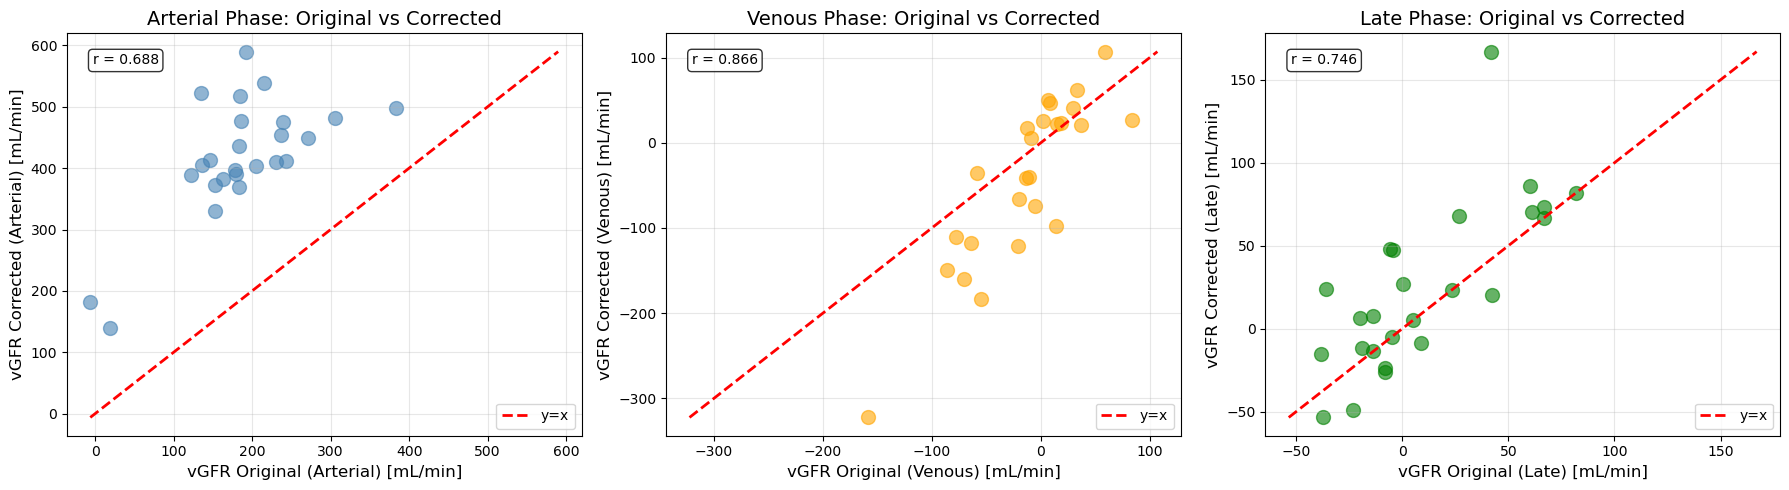


Note: Points above the red line indicate vGFR increased with correction
      Points below the red line indicate vGFR decreased with correction


In [27]:
# Visualize impact of wavefront correction
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    original_col = f'vgfr_{phase}_mean'
    corrected_col = f'vgfr_wf_{phase}_mean'
    
    axes[idx].scatter(anon_seg_egfr_df[original_col], 
                     anon_seg_egfr_df[corrected_col], 
                     alpha=0.6, s=100, color=color)
    
    # Add identity line
    min_val = min(anon_seg_egfr_df[original_col].min(), anon_seg_egfr_df[corrected_col].min())
    max_val = max(anon_seg_egfr_df[original_col].max(), anon_seg_egfr_df[corrected_col].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
    
    axes[idx].set_xlabel(f'vGFR Original ({phase.title()}) [mL/min]', fontsize=12)
    axes[idx].set_ylabel(f'vGFR Corrected ({phase.title()}) [mL/min]', fontsize=12)
    axes[idx].set_title(f'{phase.title()} Phase: Original vs Corrected', fontsize=14)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    corr = anon_seg_egfr_df[[original_col, corrected_col]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nNote: Points above the red line indicate vGFR increased with correction")
print("      Points below the red line indicate vGFR decreased with correction")

## Does Wavefront Correction Improve Correlation with eGFRc?

Compare how well original vs corrected vGFR correlates with systemic kidney function (eGFRc).

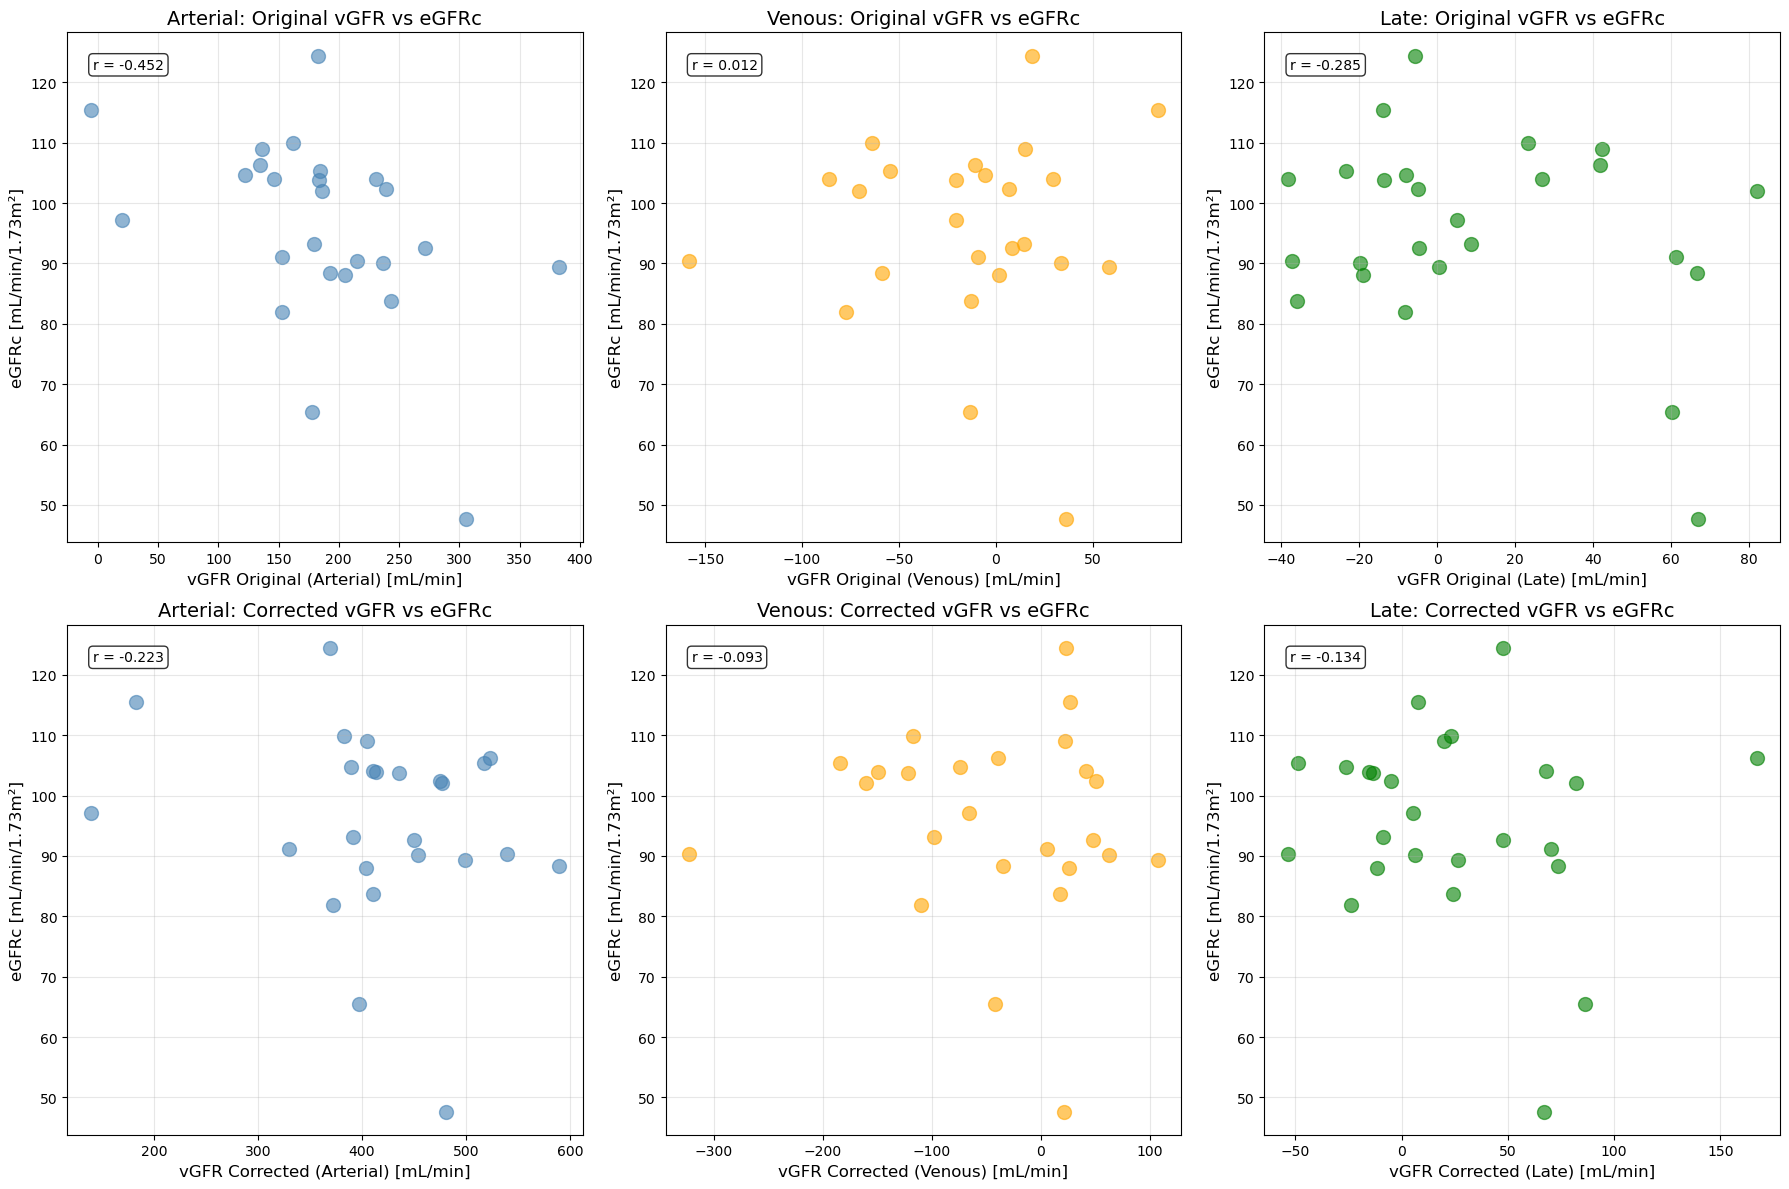


Correlation with eGFRc: Original vs Wavefront Corrected

ARTERIAL Phase:
  Original:    r = -0.452
  Corrected:   r = -0.223
  Improvement: +0.229 ✓

VENOUS Phase:
  Original:    r = 0.012
  Corrected:   r = -0.093
  Improvement: -0.105 

LATE Phase:
  Original:    r = -0.285
  Corrected:   r = -0.134
  Improvement: +0.151 ✓


In [28]:
# Compare correlation with eGFRc
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

# Top row: Original vGFR vs eGFRc
for idx, (phase, color) in enumerate(zip(phases, colors)):
    col = f'vgfr_{phase}_mean'
    
    axes[0, idx].scatter(anon_seg_egfr_df[col], anon_seg_egfr_df['egfrc'], 
                        alpha=0.6, s=100, color=color)
    axes[0, idx].set_xlabel(f'vGFR Original ({phase.title()}) [mL/min]', fontsize=12)
    axes[0, idx].set_ylabel('eGFRc [mL/min/1.73m²]', fontsize=12)
    axes[0, idx].set_title(f'{phase.title()}: Original vGFR vs eGFRc', fontsize=14)
    axes[0, idx].grid(True, alpha=0.3)
    
    corr = anon_seg_egfr_df[['egfrc', col]].corr().iloc[0, 1]
    axes[0, idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                     transform=axes[0, idx].transAxes, 
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Bottom row: Corrected vGFR vs eGFRc
for idx, (phase, color) in enumerate(zip(phases, colors)):
    col = f'vgfr_wf_{phase}_mean'
    
    axes[1, idx].scatter(anon_seg_egfr_df[col], anon_seg_egfr_df['egfrc'], 
                        alpha=0.6, s=100, color=color)
    axes[1, idx].set_xlabel(f'vGFR Corrected ({phase.title()}) [mL/min]', fontsize=12)
    axes[1, idx].set_ylabel('eGFRc [mL/min/1.73m²]', fontsize=12)
    axes[1, idx].set_title(f'{phase.title()}: Corrected vGFR vs eGFRc', fontsize=14)
    axes[1, idx].grid(True, alpha=0.3)
    
    corr = anon_seg_egfr_df[['egfrc', col]].corr().iloc[0, 1]
    axes[1, idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                     transform=axes[1, idx].transAxes, 
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print correlation comparison
print("\nCorrelation with eGFRc: Original vs Wavefront Corrected")
print("=" * 80)
for phase in phases:
    orig_col = f'vgfr_{phase}_mean'
    corr_col = f'vgfr_wf_{phase}_mean'
    
    corr_orig = anon_seg_egfr_df[['egfrc', orig_col]].corr().iloc[0, 1]
    corr_corr = anon_seg_egfr_df[['egfrc', corr_col]].corr().iloc[0, 1]
    improvement = corr_corr - corr_orig
    
    print(f"\n{phase.upper()} Phase:")
    print(f"  Original:    r = {corr_orig:.3f}")
    print(f"  Corrected:   r = {corr_corr:.3f}")
    print(f"  Improvement: {improvement:+.3f} {'✓' if improvement > 0 else ''}")

---

# First Analysis: HU Units with No Correction

This section analyzes the `gold.segmentations_with_egfr` table, which contains:
- eGFRc (matched from anonymized data)
- vGFR calculated using raw HU values (no baseline correction, no wavefront correction)
- All three phases: arterial, venous, late

## Objective:
Analyze vGFR across all phases and compare with eGFRc to understand kidney function patterns.

In [29]:
# Load gold.segmentations_with_egfr table
db_path_seg = Path('../database/egfr_data.duckdb')
conn_seg = duckdb.connect(str(db_path_seg), read_only=True)
seg_egfr_df = conn_seg.execute('SELECT * FROM gold.segmentations_with_egfr').df()
conn_seg.close()

print(f"Loaded gold.segmentations_with_egfr")
print("=" * 80)
print(f"Total records: {len(seg_egfr_df)}")
print(f"Total columns: {len(seg_egfr_df.columns)}")
print(f"\nRecords with eGFRc: {seg_egfr_df['egfrc'].notna().sum()}")
print(f"Records with vGFR (arterial): {seg_egfr_df['vgfr_arterial_mean'].notna().sum()}")
print(f"Records with vGFR (venous): {seg_egfr_df['vgfr_venous_mean'].notna().sum()}")
print(f"Records with vGFR (late): {seg_egfr_df['vgfr_late_mean'].notna().sum()}")

# Display sample
print("\nSample Data:")
print("=" * 80)
display(seg_egfr_df[['case_number', 'egfrc', 'vgfr_arterial_mean', 
                     'vgfr_venous_mean', 'vgfr_late_mean']].head(10))

Loaded gold.segmentations_with_egfr
Total records: 25
Total columns: 25

Records with eGFRc: 25
Records with vGFR (arterial): 21
Records with vGFR (venous): 22
Records with vGFR (late): 23

Sample Data:


,case_number,egfrc,vgfr_arterial_mean,vgfr_venous_mean,vgfr_late_mean
0,1,83.725219,170.088339,NaN,NaN
1,10,89.335971,328.282290,19.000501,-54.628200
2,11,106.261237,101.138678,-60.236877,2.908398
3,12,103.987913,117.899431,-21.033039,-45.819201
4,13,102.018579,160.104702,-80.819357,51.350605
5,14,91.088869,117.707181,-0.247257,-51.630196
6,15,81.894425,152.536094,-31.478356,9.690389
7,16,90.094717,139.907962,11.331098,-7.453950
8,17,109.912168,50.983196,-60.065317,-55.092092
9,18,65.404328,137.571633,NaN,-13.869181


In [30]:
# vGFR statistics by phase
print("vGFR Statistics by Phase (HU method, no corrections)")
print("=" * 80)

phases = ['arterial', 'venous', 'late']

for phase in phases:
    col = f'vgfr_{phase}_mean'
    
    print(f"\n{phase.upper()} Phase:")
    print(f"  Count:  {seg_egfr_df[col].notna().sum()}")
    print(f"  Mean:   {seg_egfr_df[col].mean():.2f} mL/min")
    print(f"  Median: {seg_egfr_df[col].median():.2f} mL/min")
    print(f"  Std:    {seg_egfr_df[col].std():.2f} mL/min")
    print(f"  Range:  [{seg_egfr_df[col].min():.2f}, {seg_egfr_df[col].max():.2f}] mL/min")

# eGFRc statistics
print(f"\neGFRc Statistics:")
print(f"  Count:  {seg_egfr_df['egfrc'].notna().sum()}")
print(f"  Mean:   {seg_egfr_df['egfrc'].mean():.2f} mL/min/1.73m²")
print(f"  Median: {seg_egfr_df['egfrc'].median():.2f} mL/min/1.73m²")
print(f"  Std:    {seg_egfr_df['egfrc'].std():.2f} mL/min/1.73m²")
print(f"  Range:  [{seg_egfr_df['egfrc'].min():.2f}, {seg_egfr_df['egfrc'].max():.2f}] mL/min/1.73m²")

vGFR Statistics by Phase (HU method, no corrections)

ARTERIAL Phase:
  Count:  21
  Mean:   153.46 mL/min
  Median: 147.48 mL/min
  Std:    69.17 mL/min
  Range:  [8.79, 328.28] mL/min

VENOUS Phase:
  Count:  22
  Mean:   -26.35 mL/min
  Median: -24.37 mL/min
  Std:    45.78 mL/min
  Range:  [-148.22, 47.57] mL/min

LATE Phase:
  Count:  23
  Mean:   -23.95 mL/min
  Median: -21.32 mL/min
  Std:    37.44 mL/min
  Range:  [-124.15, 51.35] mL/min

eGFRc Statistics:
  Count:  25
  Mean:   95.61 mL/min/1.73m²
  Median: 97.19 mL/min/1.73m²
  Std:    15.79 mL/min/1.73m²
  Range:  [47.65, 124.46] mL/min/1.73m²


## vGFR Distribution Across Phases

Visualize how vGFR varies across the three contrast phases.

C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_42176\3095850884.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vgfr_melted, x='Phase', y='vGFR', palette='Set2', ax=axes[0])
C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_42176\3095850884.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=vgfr_melted, x='Phase', y='vGFR', palette='Set2', ax=axes[1])


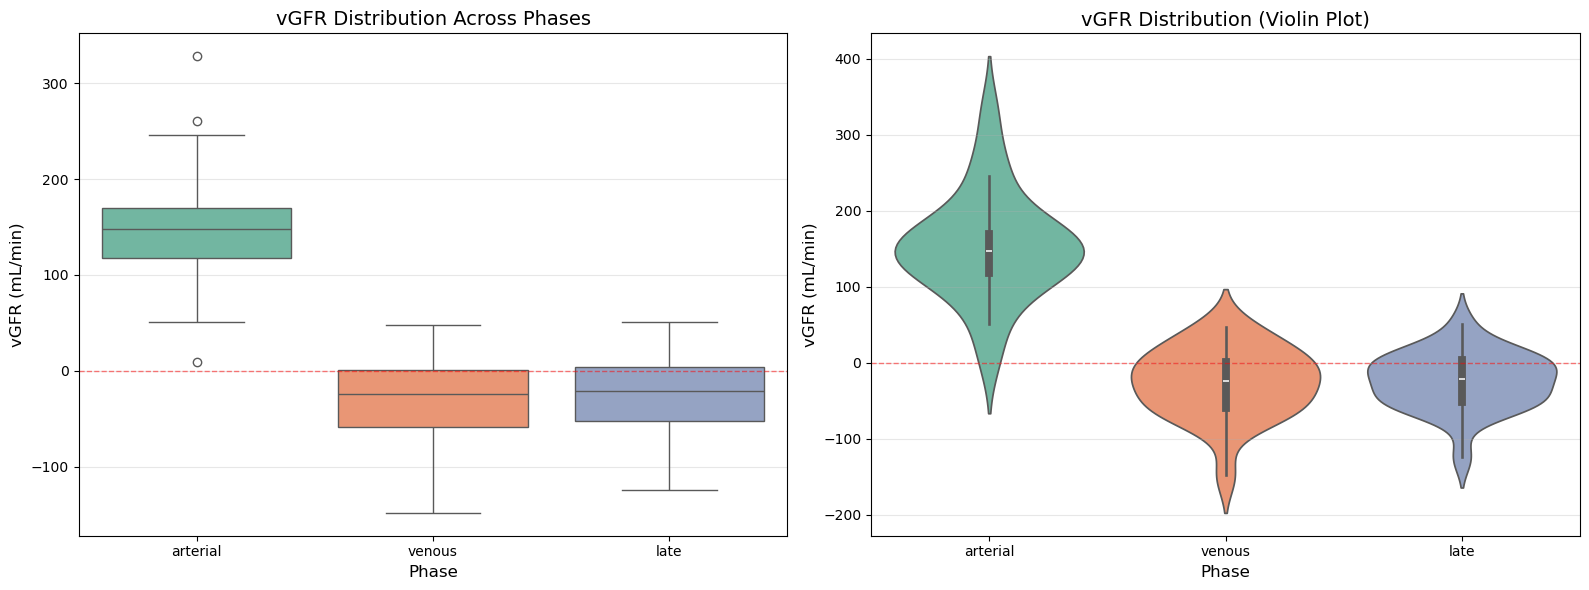


Note: Red dashed line at y=0 indicates zero vGFR
      Negative values indicate P_RV > P_RA (reverse extraction)


In [31]:
# Visualize vGFR distribution across phases
import seaborn as sns

# Prepare data for visualization
vgfr_data = seg_egfr_df[['case_number', 'vgfr_arterial_mean', 
                         'vgfr_venous_mean', 'vgfr_late_mean']].copy()
vgfr_melted = vgfr_data.melt(id_vars='case_number', 
                              var_name='Phase', 
                              value_name='vGFR')
vgfr_melted['Phase'] = vgfr_melted['Phase'].str.replace('vgfr_', '').str.replace('_mean', '')

# Create box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=vgfr_melted, x='Phase', y='vGFR', palette='Set2', ax=axes[0])
axes[0].set_xlabel('Phase', fontsize=12)
axes[0].set_ylabel('vGFR (mL/min)', fontsize=12)
axes[0].set_title('vGFR Distribution Across Phases', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Violin plot
sns.violinplot(data=vgfr_melted, x='Phase', y='vGFR', palette='Set2', ax=axes[1])
axes[1].set_xlabel('Phase', fontsize=12)
axes[1].set_ylabel('vGFR (mL/min)', fontsize=12)
axes[1].set_title('vGFR Distribution (Violin Plot)', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("\nNote: Red dashed line at y=0 indicates zero vGFR")
print("      Negative values indicate P_RV > P_RA (reverse extraction)")

## vGFR vs eGFRc Correlation

Compare volumetric GFR (from imaging) with systemic eGFR (from blood test) to assess agreement.

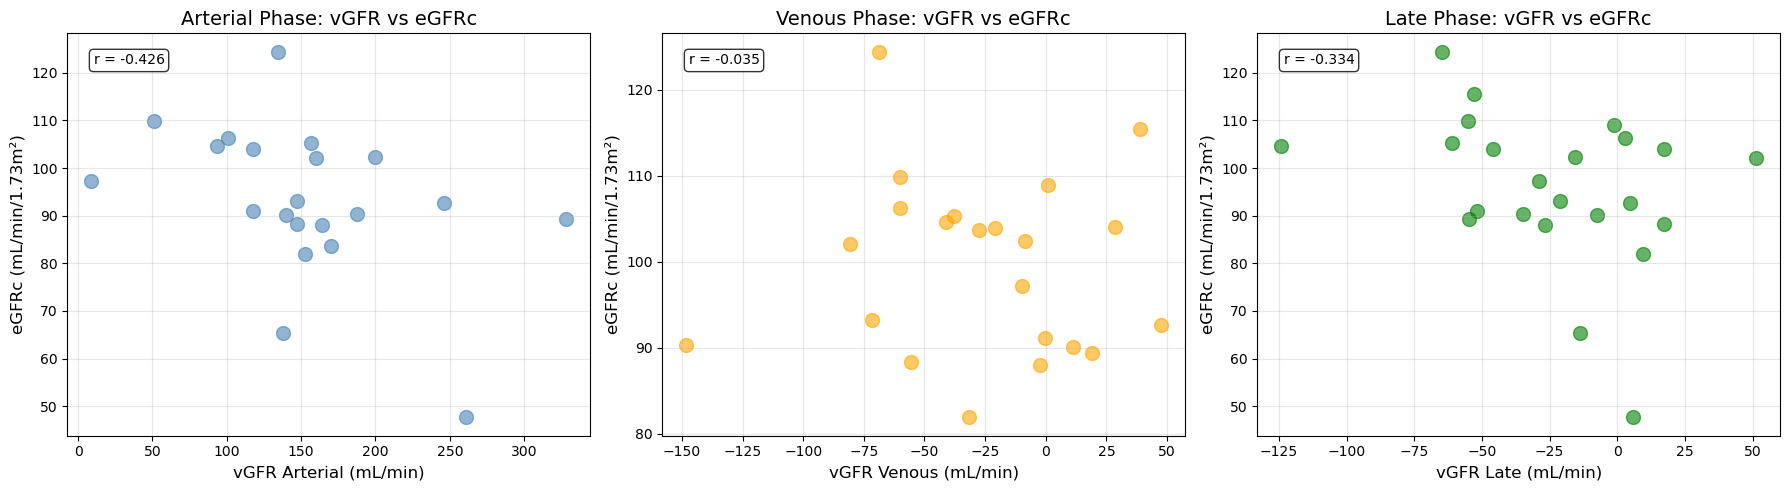


Correlation with eGFRc:
Arterial  : r = -0.426
Venous    : r = -0.035
Late      : r = -0.334


In [32]:
# vGFR vs eGFRc correlation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    col = f'vgfr_{phase}_mean'
    
    # Scatter plot: vGFR on x-axis, eGFRc on y-axis
    axes[idx].scatter(seg_egfr_df[col], seg_egfr_df['egfrc'], 
                     alpha=0.6, s=100, color=color)
    axes[idx].set_xlabel(f'vGFR {phase.title()} (mL/min)', fontsize=12)
    axes[idx].set_ylabel('eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[idx].set_title(f'{phase.title()} Phase: vGFR vs eGFRc', fontsize=14)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    corr = seg_egfr_df[[col, 'egfrc']].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print correlation summary
print("\nCorrelation with eGFRc:")
print("=" * 80)
for phase in phases:
    col = f'vgfr_{phase}_mean'
    corr = seg_egfr_df[[col, 'egfrc']].corr().iloc[0, 1]
    print(f"{phase.title():10s}: r = {corr:+.3f}")

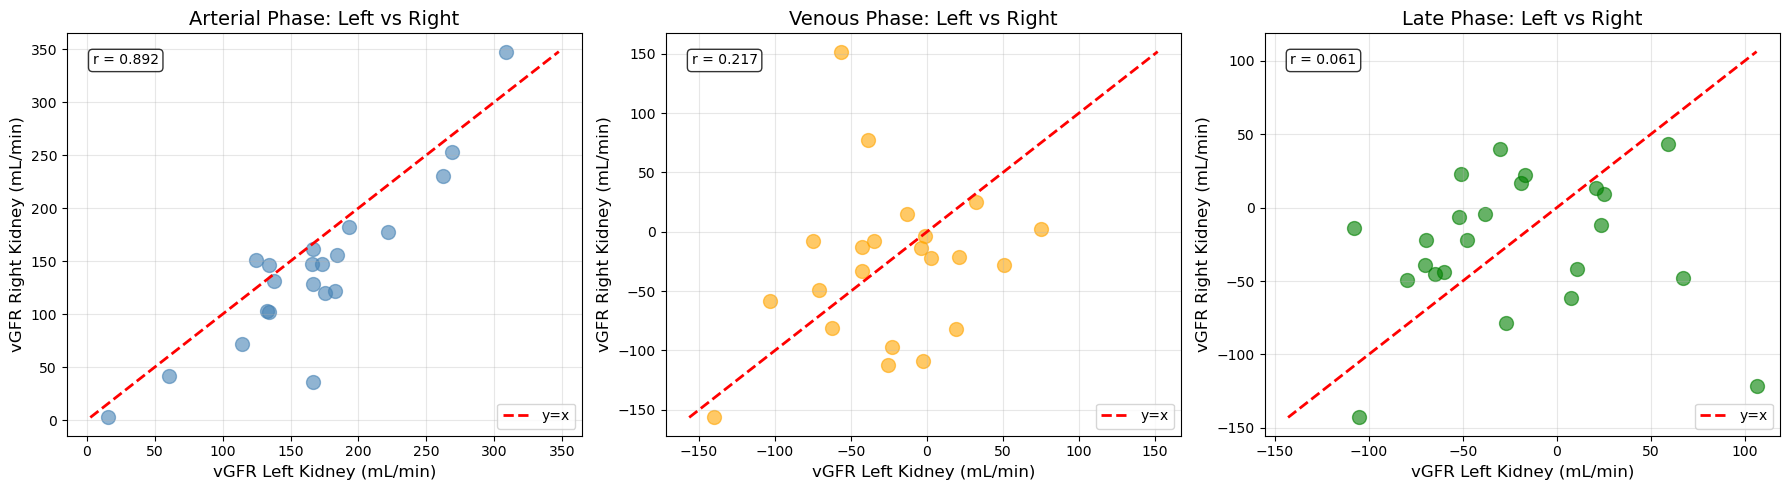


Note: Points on the red line indicate equal function in both kidneys
      Points above the line: right kidney has higher vGFR
      Points below the line: left kidney has higher vGFR


In [33]:
# Compare left vs right kidney vGFR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    left_col = f'vgfr_{phase}_left'
    right_col = f'vgfr_{phase}_right'
    
    axes[idx].scatter(seg_egfr_df[left_col], seg_egfr_df[right_col], 
                     alpha=0.6, s=100, color=color)
    
    # Add identity line
    min_val = min(seg_egfr_df[left_col].min(), seg_egfr_df[right_col].min())
    max_val = max(seg_egfr_df[left_col].max(), seg_egfr_df[right_col].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
    
    axes[idx].set_xlabel(f'vGFR Left Kidney (mL/min)', fontsize=12)
    axes[idx].set_ylabel(f'vGFR Right Kidney (mL/min)', fontsize=12)
    axes[idx].set_title(f'{phase.title()} Phase: Left vs Right', fontsize=14)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    corr = seg_egfr_df[[left_col, right_col]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nNote: Points on the red line indicate equal function in both kidneys")
print("      Points above the line: right kidney has higher vGFR")
print("      Points below the line: left kidney has higher vGFR")

---

# Back-Propagated Wavefront Correction Analysis (W_back)

This section analyzes the `gold.anon_segmentations_with_egfr` table with the new **back-propagated wavefront correction** factor.

## Theory:

The back-propagated wavefront correction factor is calculated as:

$$W_{back} = \frac{P_{RA} \cdot (1 - \frac{eGFR}{RPF})}{P_{RV}}$$

Where:
- $P_{RA}$ = Renal artery HU/concentration
- $P_{RV}$ = Renal vein HU/concentration
- $eGFR$ = Estimated GFR (using eGFRc)
- $RPF$ = Renal plasma flow (600 mL/min)

This is then applied to calculate:

$$vGFR_{back} = RPF \times \frac{P_{RA} - P_{RV} \times W_{back}}{P_{RA}}$$

## Objective:
Compare vGFR_back with eGFRc to assess if this correction improves agreement with clinical measurements.

In [34]:
# Load gold.anon_segmentations_with_egfr table
db_path_anon = Path('../database/egfr_data.duckdb')
conn_anon = duckdb.connect(str(db_path_anon), read_only=True)
anon_egfr_df = conn_anon.execute('SELECT * FROM gold.anon_segmentations_with_egfr').df()
conn_anon.close()

print(f"Loaded gold.anon_segmentations_with_egfr")
print("=" * 80)
print(f"Total records: {len(anon_egfr_df)}")
print(f"Total columns: {len(anon_egfr_df.columns)}")
print(f"\nRecords with eGFRc: {anon_egfr_df['egfrc'].notna().sum()}")
print(f"Records with W_back (arterial left): {anon_egfr_df['w_back_arterial_left'].notna().sum()}")
print(f"Records with vGFR_back (arterial): {anon_egfr_df['vgfr_back_arterial_mean'].notna().sum()}")
print(f"Records with vGFR_back (venous): {anon_egfr_df['vgfr_back_venous_mean'].notna().sum()}")
print(f"Records with vGFR_back (late): {anon_egfr_df['vgfr_back_late_mean'].notna().sum()}")

# Display sample
print("\nSample Data:")
print("=" * 80)
display(anon_egfr_df[['record_id', 'egfrc', 'w_back_arterial_left', 'w_back_arterial_right',
                      'vgfr_back_arterial_mean', 'vgfr_back_venous_mean', 
                      'vgfr_back_late_mean']].head(10))

Loaded gold.anon_segmentations_with_egfr
Total records: 25
Total columns: 114

Records with eGFRc: 25
Records with W_back (arterial left): 25
Records with vGFR_back (arterial): 25
Records with vGFR_back (venous): 25
Records with vGFR_back (late): 25

Sample Data:


,record_id,egfrc,w_back_arterial_left,w_back_arterial_right,vgfr_back_arterial_mean,vgfr_back_venous_mean,vgfr_back_late_mean
0,1,83.725219,1.472190,1.422146,83.725219,83.725219,83.725219
1,2,104.674006,1.102100,0.979321,104.674006,104.674006,104.674006
2,3,97.193088,0.874737,0.858205,97.193088,97.193088,97.193088
3,4,115.470469,0.846340,0.757495,115.470469,115.470469,115.470469
4,5,102.420559,1.449179,1.314649,102.420559,102.420559,102.420559
5,6,103.752510,1.406035,1.032896,103.752510,103.752510,103.752510
6,7,92.627864,1.642024,1.458695,92.627864,92.627864,92.627864
7,8,108.981773,1.079239,1.040544,108.981773,108.981773,108.981773
8,9,88.014682,1.329365,1.264955,88.014682,88.014682,88.014682
9,10,89.335971,2.256604,2.457869,89.335971,89.335971,89.335971


## W_back Statistics

Examine the distribution of the back-propagated wavefront correction factor across phases and kidneys.

In [35]:
# W_back statistics
print("W_back Statistics by Phase and Kidney")
print("=" * 80)

w_back_cols = [
    'w_back_arterial_left', 'w_back_arterial_right',
    'w_back_venous_left', 'w_back_venous_right',
    'w_back_late_left', 'w_back_late_right'
]

for col in w_back_cols:
    if col in anon_egfr_df.columns:
        phase_kidney = col.replace('w_back_', '').replace('_', ' ').title()
        print(f"\n{phase_kidney}:")
        print(f"  Count:  {anon_egfr_df[col].notna().sum()}")
        if anon_egfr_df[col].notna().sum() > 0:
            print(f"  Mean:   {anon_egfr_df[col].mean():.3f}")
            print(f"  Median: {anon_egfr_df[col].median():.3f}")
            print(f"  Std:    {anon_egfr_df[col].std():.3f}")
            print(f"  Range:  [{anon_egfr_df[col].min():.3f}, {anon_egfr_df[col].max():.3f}]")

W_back Statistics by Phase and Kidney

Arterial Left:
  Count:  25
  Mean:   1.315
  Median: 1.282
  Std:    0.299
  Range:  [0.846, 2.257]

Arterial Right:
  Count:  25
  Mean:   1.234
  Median: 1.158
  Std:    0.334
  Range:  [0.757, 2.458]

Venous Left:
  Count:  25
  Mean:   0.831
  Median: 0.832
  Std:    0.096
  Range:  [0.677, 1.092]

Venous Right:
  Count:  25
  Mean:   0.829
  Median: 0.823
  Std:    0.086
  Range:  [0.667, 1.019]

Late Left:
  Count:  25
  Mean:   0.852
  Median: 0.840
  Std:    0.085
  Range:  [0.713, 1.095]

Late Right:
  Count:  25
  Mean:   0.873
  Median: 0.863
  Std:    0.096
  Range:  [0.702, 1.168]


C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_42176\2598122021.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=w_back_melted, x='Phase', y='W_back', palette='Set2', ax=axes[0])
C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_42176\2598122021.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=w_back_melted, x='Kidney', y='W_back', palette='Set1', ax=axes[1])


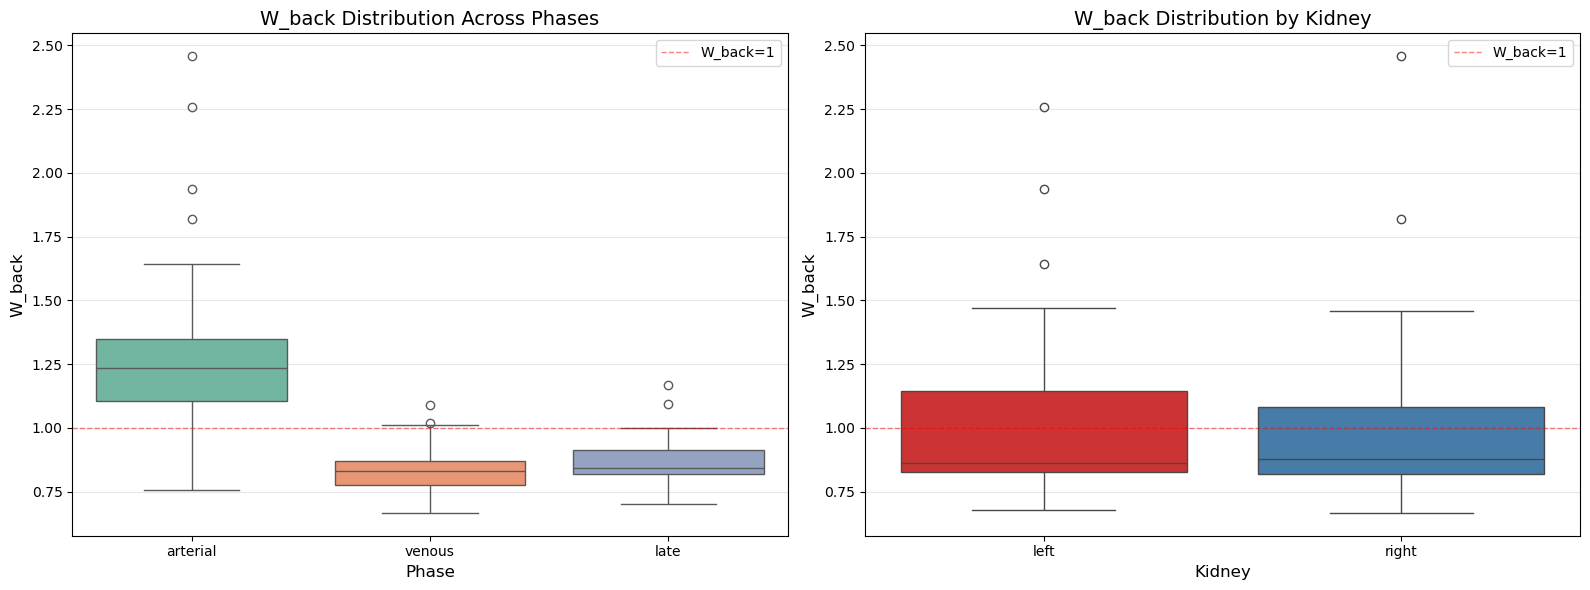


Note: Red dashed line at W_back=1 indicates no correction
      W_back > 1: Increases the effective renal vein concentration
      W_back < 1: Decreases the effective renal vein concentration


In [36]:
# Visualize W_back distribution
import seaborn as sns

# Prepare data for visualization
w_back_data = anon_egfr_df[['record_id'] + w_back_cols].copy()
w_back_melted = w_back_data.melt(id_vars='record_id', 
                                  var_name='Phase_Kidney', 
                                  value_name='W_back')
w_back_melted['Phase'] = w_back_melted['Phase_Kidney'].str.extract(r'w_back_(\w+)_')[0]
w_back_melted['Kidney'] = w_back_melted['Phase_Kidney'].str.extract(r'_(left|right)$')[0]

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot by phase
sns.boxplot(data=w_back_melted, x='Phase', y='W_back', palette='Set2', ax=axes[0])
axes[0].set_xlabel('Phase', fontsize=12)
axes[0].set_ylabel('W_back', fontsize=12)
axes[0].set_title('W_back Distribution Across Phases', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='W_back=1')
axes[0].legend()

# Box plot by kidney
sns.boxplot(data=w_back_melted, x='Kidney', y='W_back', palette='Set1', ax=axes[1])
axes[1].set_xlabel('Kidney', fontsize=12)
axes[1].set_ylabel('W_back', fontsize=12)
axes[1].set_title('W_back Distribution by Kidney', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='W_back=1')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nNote: Red dashed line at W_back=1 indicates no correction")
print("      W_back > 1: Increases the effective renal vein concentration")
print("      W_back < 1: Decreases the effective renal vein concentration")

## vGFR_back Statistics

Examine the vGFR values calculated with back-propagated wavefront correction.

In [37]:
# vGFR_back statistics by phase
print("vGFR_back Statistics by Phase (with back-propagated wavefront correction)")
print("=" * 80)

phases = ['arterial', 'venous', 'late']

for phase in phases:
    col = f'vgfr_back_{phase}_mean'
    
    print(f"\n{phase.upper()} Phase:")
    print(f"  Count:  {anon_egfr_df[col].notna().sum()}")
    if anon_egfr_df[col].notna().sum() > 0:
        print(f"  Mean:   {anon_egfr_df[col].mean():.2f} mL/min")
        print(f"  Median: {anon_egfr_df[col].median():.2f} mL/min")
        print(f"  Std:    {anon_egfr_df[col].std():.2f} mL/min")
        print(f"  Range:  [{anon_egfr_df[col].min():.2f}, {anon_egfr_df[col].max():.2f}] mL/min")

# eGFRc statistics for comparison
print(f"\neGFRc Statistics (for comparison):")
print(f"  Count:  {anon_egfr_df['egfrc'].notna().sum()}")
if anon_egfr_df['egfrc'].notna().sum() > 0:
    print(f"  Mean:   {anon_egfr_df['egfrc'].mean():.2f} mL/min/1.73m²")
    print(f"  Median: {anon_egfr_df['egfrc'].median():.2f} mL/min/1.73m²")
    print(f"  Std:    {anon_egfr_df['egfrc'].std():.2f} mL/min/1.73m²")
    print(f"  Range:  [{anon_egfr_df['egfrc'].min():.2f}, {anon_egfr_df['egfrc'].max():.2f}] mL/min/1.73m²")

vGFR_back Statistics by Phase (with back-propagated wavefront correction)

ARTERIAL Phase:
  Count:  25
  Mean:   95.61 mL/min
  Median: 97.19 mL/min
  Std:    15.79 mL/min
  Range:  [47.65, 124.46] mL/min

VENOUS Phase:
  Count:  25
  Mean:   95.61 mL/min
  Median: 97.19 mL/min
  Std:    15.79 mL/min
  Range:  [47.65, 124.46] mL/min

LATE Phase:
  Count:  25
  Mean:   95.61 mL/min
  Median: 97.19 mL/min
  Std:    15.79 mL/min
  Range:  [47.65, 124.46] mL/min

eGFRc Statistics (for comparison):
  Count:  25
  Mean:   95.61 mL/min/1.73m²
  Median: 97.19 mL/min/1.73m²
  Std:    15.79 mL/min/1.73m²
  Range:  [47.65, 124.46] mL/min/1.73m²


C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_42176\2094396317.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vgfr_back_melted, x='Phase', y='vGFR_back', palette='Set2', ax=axes[0])
C:\Users\FilipeFurlanBellotti\AppData\Local\Temp\ipykernel_42176\2094396317.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=vgfr_back_melted, x='Phase', y='vGFR_back', palette='Set2', ax=axes[1])


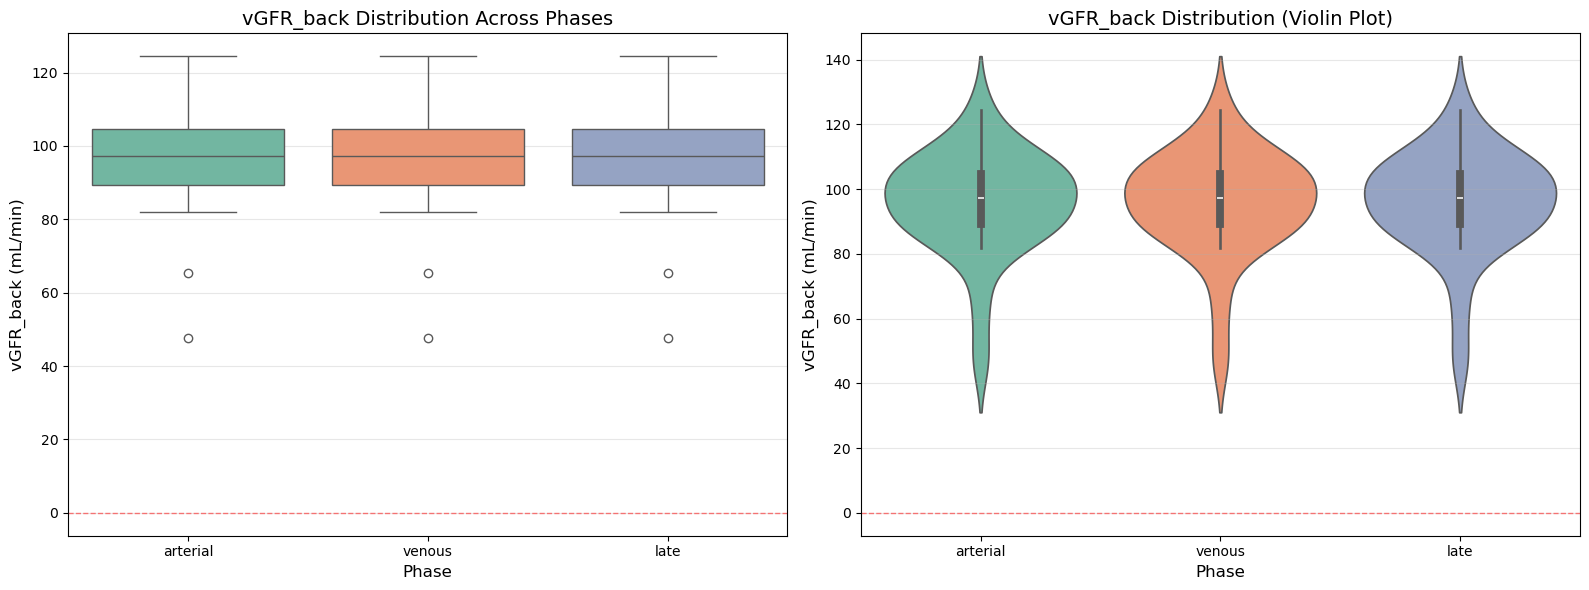


Note: Red dashed line at y=0 indicates zero vGFR
      Negative values indicate reverse extraction even after correction


In [38]:
# Visualize vGFR_back distribution across phases
vgfr_back_data = anon_egfr_df[['record_id', 'vgfr_back_arterial_mean', 
                                'vgfr_back_venous_mean', 'vgfr_back_late_mean']].copy()
vgfr_back_melted = vgfr_back_data.melt(id_vars='record_id', 
                                        var_name='Phase', 
                                        value_name='vGFR_back')
vgfr_back_melted['Phase'] = vgfr_back_melted['Phase'].str.replace('vgfr_back_', '').str.replace('_mean', '')

# Create box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=vgfr_back_melted, x='Phase', y='vGFR_back', palette='Set2', ax=axes[0])
axes[0].set_xlabel('Phase', fontsize=12)
axes[0].set_ylabel('vGFR_back (mL/min)', fontsize=12)
axes[0].set_title('vGFR_back Distribution Across Phases', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Violin plot
sns.violinplot(data=vgfr_back_melted, x='Phase', y='vGFR_back', palette='Set2', ax=axes[1])
axes[1].set_xlabel('Phase', fontsize=12)
axes[1].set_ylabel('vGFR_back (mL/min)', fontsize=12)
axes[1].set_title('vGFR_back Distribution (Violin Plot)', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("\nNote: Red dashed line at y=0 indicates zero vGFR")
print("      Negative values indicate reverse extraction even after correction")

## vGFR_back vs eGFRc Correlation

Compare vGFR_back (with back-propagated wavefront correction) with eGFRc to assess agreement.

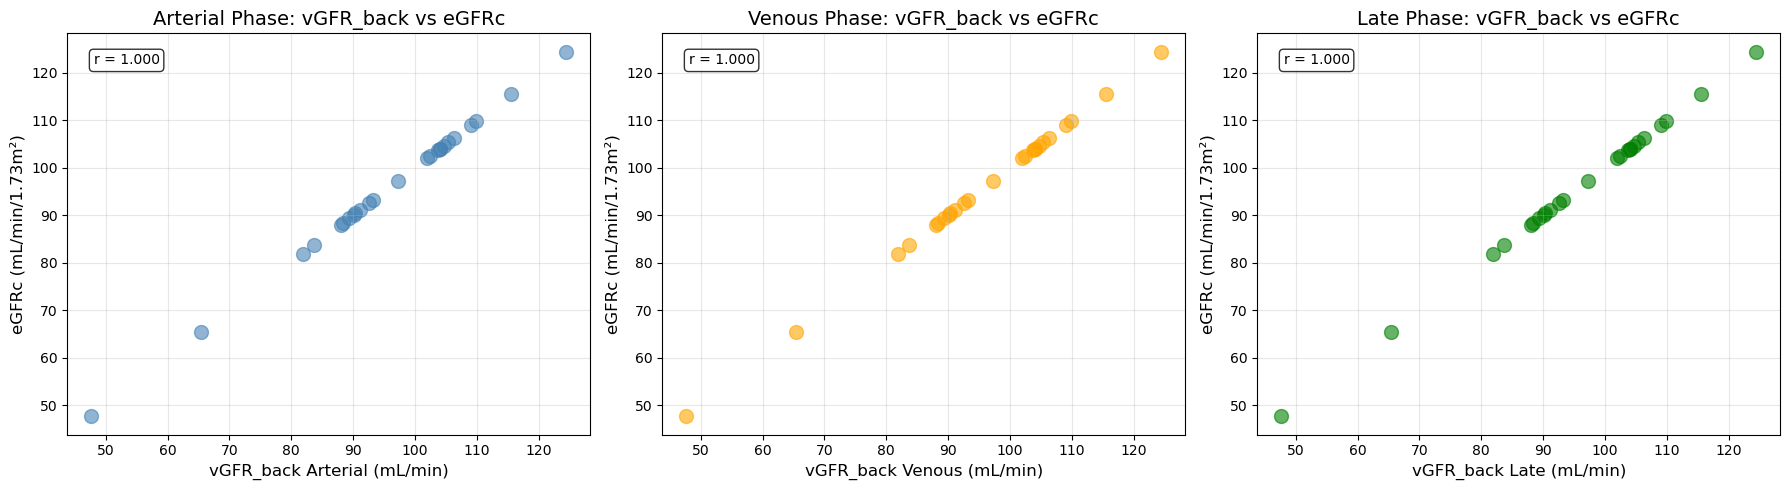


Correlation with eGFRc:
Arterial  : r = +1.000
Venous    : r = +1.000
Late      : r = +1.000


In [39]:
# vGFR_back vs eGFRc correlation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    col = f'vgfr_back_{phase}_mean'
    
    # Scatter plot: vGFR_back on x-axis, eGFRc on y-axis
    axes[idx].scatter(anon_egfr_df[col], anon_egfr_df['egfrc'], 
                     alpha=0.6, s=100, color=color)
    axes[idx].set_xlabel(f'vGFR_back {phase.title()} (mL/min)', fontsize=12)
    axes[idx].set_ylabel('eGFRc (mL/min/1.73m²)', fontsize=12)
    axes[idx].set_title(f'{phase.title()} Phase: vGFR_back vs eGFRc', fontsize=14)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    valid_data = anon_egfr_df[[col, 'egfrc']].dropna()
    if len(valid_data) > 1:
        corr = valid_data.corr().iloc[0, 1]
        axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                       transform=axes[idx].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print correlation summary
print("\nCorrelation with eGFRc:")
print("=" * 80)
for phase in phases:
    col = f'vgfr_back_{phase}_mean'
    valid_data = anon_egfr_df[[col, 'egfrc']].dropna()
    if len(valid_data) > 1:
        corr = valid_data.corr().iloc[0, 1]
        print(f"{phase.title():10s}: r = {corr:+.3f}")
    else:
        print(f"{phase.title():10s}: Insufficient data")

## Comparison: vGFR vs vGFR_back

Compare the original vGFR (no correction) with vGFR_back (with back-propagated wavefront correction).

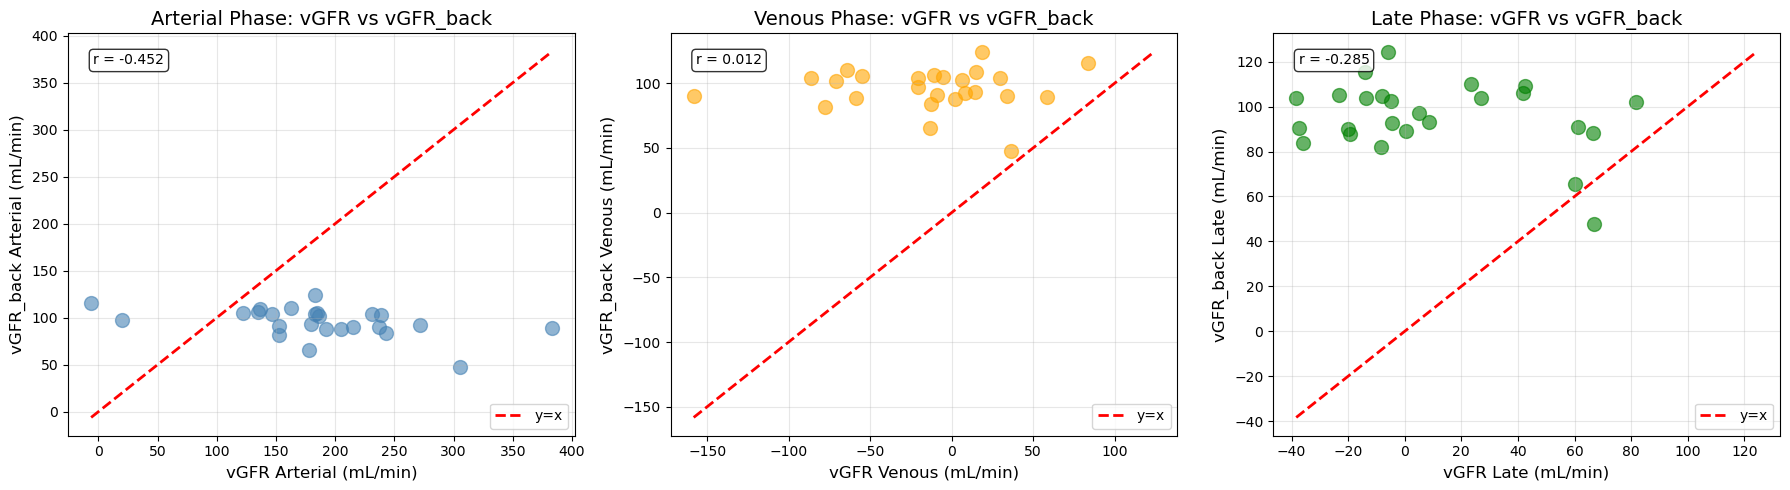


Note: Points on the red line indicate no change from correction
      Points above the line: W_back correction increased vGFR
      Points below the line: W_back correction decreased vGFR


In [40]:
# Compare vGFR vs vGFR_back
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phases = ['arterial', 'venous', 'late']
colors = ['steelblue', 'orange', 'green']

for idx, (phase, color) in enumerate(zip(phases, colors)):
    vgfr_col = f'vgfr_{phase}_mean'
    vgfr_back_col = f'vgfr_back_{phase}_mean'
    
    # Scatter plot: vGFR on x-axis, vGFR_back on y-axis
    axes[idx].scatter(anon_egfr_df[vgfr_col], anon_egfr_df[vgfr_back_col], 
                     alpha=0.6, s=100, color=color)
    
    # Add identity line
    all_vals = pd.concat([anon_egfr_df[vgfr_col], anon_egfr_df[vgfr_back_col]]).dropna()
    if len(all_vals) > 0:
        min_val = all_vals.min()
        max_val = all_vals.max()
        axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
    
    axes[idx].set_xlabel(f'vGFR {phase.title()} (mL/min)', fontsize=12)
    axes[idx].set_ylabel(f'vGFR_back {phase.title()} (mL/min)', fontsize=12)
    axes[idx].set_title(f'{phase.title()} Phase: vGFR vs vGFR_back', fontsize=14)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate correlation
    valid_data = anon_egfr_df[[vgfr_col, vgfr_back_col]].dropna()
    if len(valid_data) > 1:
        corr = valid_data.corr().iloc[0, 1]
        axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                       transform=axes[idx].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nNote: Points on the red line indicate no change from correction")
print("      Points above the line: W_back correction increased vGFR")
print("      Points below the line: W_back correction decreased vGFR")